In [ ]:
#########################################
#DEEP

In [2]:
#Deep Convective Parcels Profile
##### viewing tracking algorithm results
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import h5py

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/Project/'
data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
parcel=xr.open_dataset(dir+'cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
whereCL=xr.open_dataset(dir+'tracking_algorithms/whereCL_4_0622.nc').load() #***
whereCL=whereCL.isel(time=slice(0,len(data['time'])))

In [3]:
#OUT_NZ

# out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_combined.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_combined.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

out_nz=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_nz[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_nz[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_nz[:,0] == elem)[0] 
    extras=idx[np.where(out_nz[idx,5]!=np.min(out_nz[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_nz), dtype=bool); mask[lst] = False
out_nz=out_nz[mask]; 
###############################################################################

out_nz=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];print('list of first 10 ignored parcels');print(save_nz[:5])
placeholder=out_nz.copy(); run=True
################################################################################
# print(f'there are a total of {len(out_nz)} SBZ parcels and {len(save_nz)} forgotten parcels')

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def threshold(zthresh):
    out_nz=placeholder.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>zthresh):
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz, extendrange
    # print(out_nz)
##############################################################

convectivelevel=6 #6km
[out_nz,extendrange]=threshold(convectivelevel)

print('list of first 10 SBZ parcels'); print(out_nz[:15])
print(f'there are a total of {len(out_nz)} SBZ parcels and {len(save_nz)} forgotten parcels')

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
list of first 10 ignored parcels
[[34 302 76 0.7418956298828125 34 37]
 [246 338 77 0.33685012817382814 2 11]
 [365 357 3 0.658669677734375 115 121]
 [363 440 62 0.18019241333007813 6 14]
 [483 465 43 0.2835696716308594 27 33]]
list of first 10 SBZ parcels
[[452 334 53 0.1520338897705078 43 48]
 [704 374 63 0.24067965698242189 57 62]
 [885 300 10 0.11673685455322266 59 65]
 [1022 37

In [4]:
# #LIMITING TO SBZ REGION (UNCOMMENT IF USING)
# #####################################################################################
# # # IF LIMITING TO INVESTIGATE SEABREEZE, UNCOMMENT THIS SECTION
# # #LIMITING TIME
# # #t in (0,50)
# # data=data.isel(time=slice(0,50))

# # #LIMITING X
# # #x in (-20,100) ==> (256-20,256+100) #### how to limit xh and xf in data
# # kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)
# # xf_range=slice(int(256*kms)-20,int(256*kms)+100)
# # xh_range=slice(int(256*kms)-20,int(256*kms)+100)
# # data=data.isel(xf=xf_range,xh=xh_range)

# # # #TESTING
# # # # data['qvflux'].isel(time=49).plot()
# # # data['qvflux'].isel(time=50,xh=slice(0,356)).plot()
# # # plt.axvline(-20,color='white')
# # # plt.axvline(100-2,color='white')
# # ####################################################################################


# #LIMITING TIME
# out_nz=out_nz[np.where(out_nz[:,4]<=50)]
# #LIMITING X
# x = parcel['x'].isel(
#     xh=xr.DataArray(out_nz[:, 0].astype(int), dims='c'),
#     time=xr.DataArray(out_nz[:, 4].astype(int), dims='c')
# )
# xf=data['xf'].values*1000; which_x=np.searchsorted(xf,x)-1; which_x=np.where(which_x == -1, 0, which_x) #finds which x layer parcel in

# kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)
# xh_range=np.arange(int(256*kms)-20,int(256*kms)+100+1)
# out_nz=out_nz[np.where((out_nz>=np.min(xh_range)) & (out_nz<=np.max(xh_range)))[0]]

# print('list of first 10 SBZ parcels'); print(out_nz[:15])
# print(f'there are a total of {len(out_nz)} SBZ parcels and {len(save_nz)} forgotten parcels')

In [13]:
def grid_location(x,y,z):
    xf=data['xf'].values*1000; which_xh=np.searchsorted(xf,x)-1; which_xh=np.where(which_xh == -1, 0, which_xh) #finds which x layer parcel in
    yf=data['yf'].values*1000; which_yh=np.searchsorted(yf,y)-1; which_yh=np.where(which_yh == -1, 0, which_yh) #finds which y layer parcel in
    zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in   
    return which_zh,which_yh,which_xh
    
# def grid_location(x,y,z): #faster
#     #finding xf and yf
#     ybins=data['yf'].values*1000; dy=ybins[1]-ybins[0] #1000
#     xbins=data['xf'].values*1000; dx=xbins[1]-xbins[0] #1000
#     dy=np.round(dy);dx=np.round(dx)

#     #digitizing
#     zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in 
#     if which_zh.ndim==0:
#         which_zh=np.array([which_zh])
#     which_yh=np.floor(y/dy).astype(int)+np.where(data['yf']==0)[0]
#     which_xh=np.floor(x/dx).astype(int)+np.where(data['xf']==0)[0]

#     #fixing boundaries
#     which_zh[np.where(which_zh==len(data['zh']))]-=1
#     which_yh[np.where(which_yh==len(data['yh']))]-=1
#     which_xh[np.where(which_xh==len(data['xh']))]-=1
#     return which_zh,which_yh,which_xh

x=parcel['x'];y=parcel['y'];z=parcel['z']
which_z,which_y,which_x=grid_location(x,y,z)

#Makes np.where style mask for deep parcel locations
######################################################

#Setting up run for deep convective parcels
# np.arange(Np)==>out_nz[:,0]
# np.arange(Nt)==>out_nz[:,4]
col4 = out_nz[:, 4].astype(int)
# col5 = out_nz[:, 5].astype(int)
col5 = out_nz[:, 5].astype(int) + 2 #add another 10 minutes to each trajectory
ranges = [np.arange(start, end + 1) for start, end in zip(col4, col5)]
indexes = out_nz[:,0]
indexranges = [np.full_like(r, fill_value=index) for r, index in zip(ranges, indexes)]
totalelements=sum(len(arr) for arr in ranges)
print(f'running for total of {totalelements} elements')


deep_t,deep_z,deep_y,deep_x=[],[],[],[]
for R in np.arange(len(ranges)):
    tup=(ranges[R],indexranges[R])
    deep_t.extend(ranges[R])
    deep_z.extend(which_z[tup])
    deep_y.extend(which_y[tup])
    deep_x.extend(which_x[tup])
deep_t=np.array(deep_t);deep_z=np.array(deep_z);deep_y=np.array(deep_y);deep_x=np.array(deep_x)
position=(deep_t, deep_z, deep_y, deep_x)
print('done')

running for total of 3118 elements
done


In [ ]:
#Deep Parcels Lagrangian Parcels Profile (OPTIMIZED) 

#W Budgets

#Making vertical profile of cloudy updrafts
print('loading neccessary variables')
if 'emptylike' not in globals():
    #Full Variables (W, QV, QC, QI)
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qv data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qi data
    qc_plus_qi=qc_data+qi_data
    emptylike=True
    
#W Budget Variables
variable='wb_hadv'; one_data=data[variable].data #'w budget: horizontal advection (non-diff component)'
variable='wb_vadv'; two_data=data[variable].data #'w budget: vertical advection (non-diff component)'
variable='wb_hidiff'; three_data=data[variable].data #'w budget: horiz implicit diffusion'
variable='wb_vidiff'; four_data=data[variable].data #'w budget: vert implicit diffusion'
variable='wb_hturb'; five_data=data[variable].data #'w budget: horizontal parameterized turbulence'
variable='wb_vturb'; six_data=data[variable].data #'w budget: vertical parameterized turbulence'
variable='wb_pgrad'; seven_data=data[variable].data #'w budget: pressure gradient'
variable='wb_rdamp'; eight_data=data[variable].data #'w budget: Rayleigh damper'
variable='wb_buoy'; nine_data=data[variable].data #'w budget: buoyancy'
print('done loading')
    


types=['all','general','cloudy']
vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_rdamp',
    'wb_buoy'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    global all_thresh,w_thresh,qcqi_thresh
    all_thresh=-1e6
    w_thresh=1 #m/s
    qcqi_thresh=1e-6 #kg/kg
   
    
    #create profile array
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    # position=(which_t.flatten(), which_z.flatten(), which_y.values.flatten(), which_x.values.flatten())
    lagrangian_w=w_data[position]
    lagrangian_qcplusqi=qc_plus_qi[position]
    
    for var in vars:
        print(f"variable {var}")
        if var=='w':
            lagrangian_var=w_data[position]
        elif var=='wb_hadv':
            lagrangian_var=one_data[position]
        elif var=='wb_vadv':
            lagrangian_var=two_data[position] 
        elif var=='wb_hidiff':
            lagrangian_var=three_data[position]
        elif var=='wb_vidiff':
            lagrangian_var=four_data[position] 
        elif var=='wb_hturb':
            lagrangian_var=five_data[position]
        elif var=='wb_vturb':
            lagrangian_var=six_data[position] 
        elif var=='wb_pgrad':
            lagrangian_var=seven_data[position]
        elif var=='wb_rdamp':
            lagrangian_var=eight_data[position] 
        elif var=='wb_buoy':
            lagrangian_var=nine_data[position] 

              
        #if w_zdata greater than threshold, add to profile z column and add count
        if type=='all':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=deep_z.flatten()[np.where(lagrangian_w>=all_thresh)]
        elif type=='general':
            masked_var=lagrangian_var[np.where(lagrangian_w>=w_thresh)]
            masked_z=deep_z.flatten()[np.where(lagrangian_w>=w_thresh)]
        elif type=='cloudy':
            masked_var=lagrangian_var[np.where((lagrangian_w>=w_thresh)&(lagrangian_qcplusqi>=qcqi_thresh))]
            masked_z=deep_z.flatten()[np.where((lagrangian_w>=w_thresh)&(lagrangian_qcplusqi>=qcqi_thresh))]
        
            
        for count,(kh,value) in enumerate(zip(masked_z,masked_var)):
            # if np.mod(count,200)==0: print(f"{np.round(count*100/len(masked_z),1)}% done")
            globals()[f"profile_{var}"][kh,0]+=value #adds data to first column
            globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column
    
    if type=='all':
        output_file=dir+f'tracking_algorithms/plots/job_out/deep_WBUDGET_profile_{convectivelevel}km_all_wthresh{w_thresh}-.h5' #-limited
    elif type=='general':
        output_file=dir+f'tracking_algorithms/plots/job_out/deep_WBUDGET_profile_{convectivelevel}km_general_wthresh{w_thresh}-.h5'
    elif type=='cloudy':
        output_file=dir+f'tracking_algorithms/plots/job_out/deep_WBUDGET_profile_{convectivelevel}km_cloudy_wthresh{w_thresh}-.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_w', data=profile_w, compression="gzip")
        f.create_dataset('profile_wb_hadv', data=profile_wb_hadv, compression="gzip")
        f.create_dataset('profile_wb_vadv', data=profile_wb_vadv, compression="gzip")
        f.create_dataset('profile_wb_hidiff', data=profile_wb_hidiff, compression="gzip")
        f.create_dataset('profile_wb_vidiff', data=profile_wb_vidiff, compression="gzip")
        f.create_dataset('profile_wb_hturb', data=profile_wb_hturb, compression="gzip")
        f.create_dataset('profile_wb_vturb', data=profile_wb_vturb, compression="gzip")
        f.create_dataset('profile_wb_pgrad', data=profile_wb_pgrad, compression="gzip")
        f.create_dataset('profile_wb_rdamp', data=profile_wb_rdamp, compression="gzip")
        f.create_dataset('profile_wb_buoy', data=profile_wb_buoy, compression="gzip")
    print('done')

loading neccessary variables


currently on type all
currently on type general
currently on type cloudy


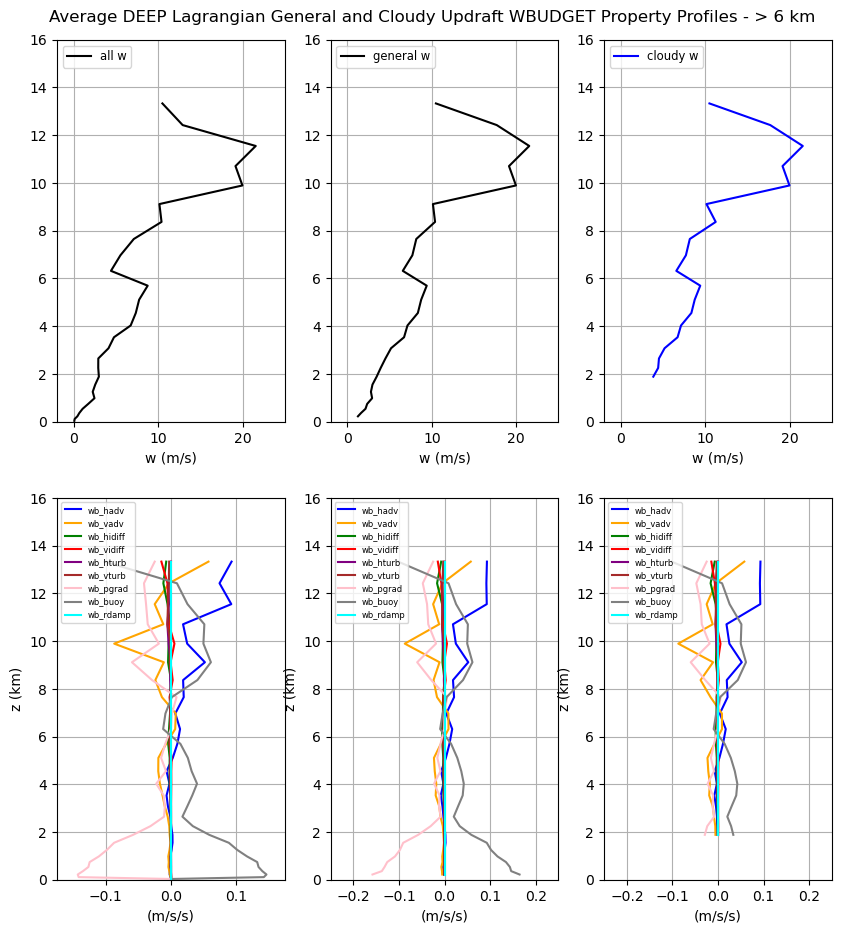

In [82]:
#W BUDGETS
w_thresh=1
convectivelevel=6

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(10, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"Average DEEP Lagrangian General and Cloudy Updraft WBUDGET Property Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","general","cloudy"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'tracking_algorithms/plots/job_out/deep_WBUDGET_profile_{convectivelevel}km_all_wthresh{w_thresh}-.h5' #-limited
        elif type=='general':
            input_file=dir+f'tracking_algorithms/plots/job_out/deep_WBUDGET_profile_{convectivelevel}km_general_wthresh{w_thresh}-.h5'
        elif type=='cloudy':
            input_file=dir+f'tracking_algorithms/plots/job_out/deep_WBUDGET_profile_{convectivelevel}km_cloudy_wthresh{w_thresh}-.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_rdamp = np.array(f['profile_wb_rdamp'])  # w budget: Rayleigh damper
        profile_wb_buoy = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy',
    'wb_rdamp'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis.set_xlim(-2,25)
        axis=ax4
    if type=='general':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis.set_xlim(-2,25)
        axis=ax5
    if type=='cloudy':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[1])
        axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis.set_xlim(-2,25)
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        axis.legend(loc='upper left', fontsize=6); #add legend

        if type=='all':
            axis.set_xlim(left=-0.175,right=0.175)
        elif type=='general':
            axis.set_xlim(left=-0.25,right=0.25)
        elif type=='cloudy':
            axis.set_xlim(left=-0.25,right=0.25)
#save plot
if dim=='1km':
    plt.savefig(dir+f'tracking_algorithms/plots/1km_DEEP_eulerian_generalvscloudy_updraft_WBUDGET_profile_wthresh{w_thresh}-.jpg', bbox_inches='tight', dpi=300) 
#-limited

In [ ]:
##############################################

In [35]:
#Deep Parcels Lagrangian Parcels Profile (OPTIMIZED) 

#QV Budgets

#Making vertical profile of cloudy updrafts
print('loading neccessary variables')
if 'emptylike' not in globals():
    #Full Variables (W, QV, QC, QI)
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qv data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qi data
    qc_plus_qi=qc_data+qi_data
    emptylike=True

#QV Budget Variables
variable='qvb_hadv'; one_data=data[variable].data #'qv budget: horizontal advection (non-diff component)'
variable='qvb_vadv'; two_data=data[variable].data #'qv budget: vertical advection (non-diff component)'
variable='qvb_hidiff'; three_data=data[variable].data #'qv budget: horiz implicit diffusion'
variable='qvb_vidiff'; four_data=data[variable].data #'qv budget: vert implicit diffusion'
variable='qvb_hturb'; five_data=data[variable].data #'qv budget: horizontal parameterized turbulence'
variable='qvb_vturb'; six_data=data[variable].data #'qv budget: vertical parameterized turbulence'
variable='qvb_mp'; seven_data=data[variable].data #'qv budget: microphysics scheme'

# #QV Tendency Variables
# variable='qt_cond'; eight_data=data[variable].data #'qv tendency: condensation'
# variable='qt_evac'; nine_data=data[variable].data #'qv tendency: cloudwater evaporation'
# variable='qt_evar'; ten_data=data[variable].data #'qv tendency: rainwater evaporation'
print('done loading')


types=['all','general','cloudy']
vars = [
    'qv',
    'qvb_hadv',
    'qvb_vadv',
    'qvb_hidiff',
    'qvb_vidiff',
    'qvb_hturb',
    'qvb_vturb',
    'qvb_mp'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    global all_thresh,w_thresh,qcqi_thresh
    all_thresh=-1e6
    w_thresh=1 #m/s
    qcqi_thresh=1e-6 #kg/kg
   
    
    #create profile array
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    # position=(which_t.flatten(), which_z.flatten(), which_y.values.flatten(), which_x.values.flatten())
    lagrangian_w=w_data[position]
    lagrangian_qcplusqi=qc_plus_qi[position]
    
    for var in vars:
        print(f"variable {var}")
        if var=='qv':
            lagrangian_var=qv_data[position]
        elif var=='qvb_hadv':
            lagrangian_var=one_data[position]
        elif var=='qvb_vadv':
            lagrangian_var=two_data[position] 
        elif var=='qvb_hidiff':
            lagrangian_var=three_data[position]
        elif var=='qvb_vidiff':
            lagrangian_var=four_data[position] 
        elif var=='qvb_hturb':
            lagrangian_var=five_data[position]
        elif var=='qvb_vturb':
            lagrangian_var=six_data[position] 
        elif var=='qvb_mb':
            lagrangian_var=seven_data[position]
              
        #if w_zdata greater than threshold, add to profile z column and add count
        if type=='all':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=deep_z.flatten()[np.where(lagrangian_w>=all_thresh)]
        elif type=='general':
            masked_var=lagrangian_var[np.where(lagrangian_w>=w_thresh)]
            masked_z=deep_z.flatten()[np.where(lagrangian_w>=w_thresh)]
        elif type=='cloudy':
            masked_var=lagrangian_var[np.where((lagrangian_w>=w_thresh)&(lagrangian_qcplusqi>=qcqi_thresh))]
            masked_z=deep_z.flatten()[np.where((lagrangian_w>=w_thresh)&(lagrangian_qcplusqi>=qcqi_thresh))]
        
            
        for count,(kh,value) in enumerate(zip(masked_z,masked_var)):
            # if np.mod(count,200)==0: print(f"{np.round(count*100/len(masked_z),1)}% done")
            globals()[f"profile_{var}"][kh,0]+=value #adds data to first column
            globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column
    
    if type=='all':
        output_file=dir+f'tracking_algorithms/plots/job_out/deep_QVBUDGET_profile_{convectivelevel}km_all_wthresh{w_thresh}-.h5'
    elif type=='general':
        output_file=dir+f'tracking_algorithms/plots/job_out/deep_QVBUDGET_profile_{convectivelevel}km_general_wthresh{w_thresh}-.h5'
    elif type=='cloudy':
        output_file=dir+f'tracking_algorithms/plots/job_out/deep_QVBUDGET_profile_{convectivelevel}km_cloudy_wthresh{w_thresh}-.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
        f.create_dataset('profile_qvb_hadv', data=profile_qvb_hadv, compression="gzip")
        f.create_dataset('profile_qvb_vadv', data=profile_qvb_vadv, compression="gzip")
        f.create_dataset('profile_qvb_hidiff', data=profile_qvb_hidiff, compression="gzip")
        f.create_dataset('profile_qvb_vidiff', data=profile_qvb_vidiff, compression="gzip")
        f.create_dataset('profile_qvb_hturb', data=profile_qvb_hturb, compression="gzip")
        f.create_dataset('profile_qvb_vturb', data=profile_qvb_vturb, compression="gzip")
        f.create_dataset('profile_qvb_mp', data=profile_qvb_mp, compression="gzip")
    print('done')

loading neccessary variables
done loading
type all
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done
type general
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done
type cloudy
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done


currently on type all
currently on type general
currently on type cloudy


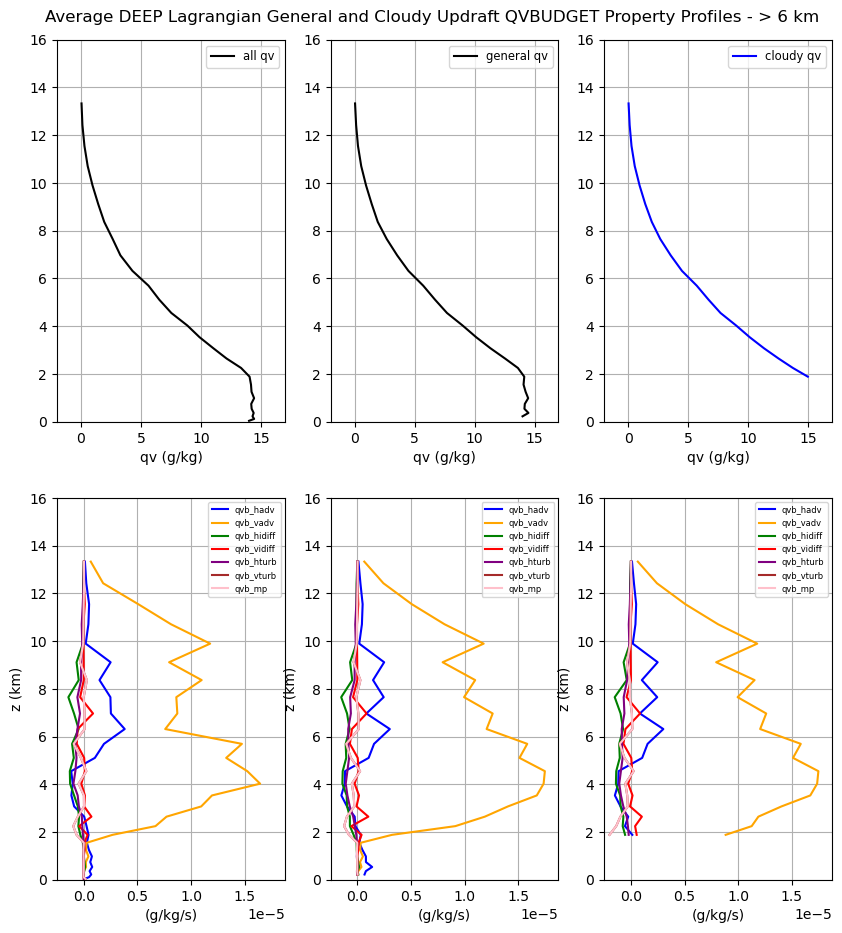

In [88]:
#QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(10, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"Average DEEP Lagrangian General and Cloudy Updraft QVBUDGET Property Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","general","cloudy"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'tracking_algorithms/plots/job_out/deep_QVBUDGET_profile_{convectivelevel}km_all_wthresh{w_thresh}-.h5' #limited
        elif type=='general':
            input_file=dir+f'tracking_algorithms/plots/job_out/deep_QVBUDGET_profile_{convectivelevel}km_general_wthresh{w_thresh}-.h5'
        elif type=='cloudy':
            input_file=dir+f'tracking_algorithms/plots/job_out/deep_QVBUDGET_profile_{convectivelevel}km_cloudy_wthresh{w_thresh}-.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
    out_qv[:,0]*=1000

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis.set_xlim(-2,17)
        axis=ax4
    elif type=='general':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis.set_xlim(-2,17)
        axis=ax5
    elif type=='cloudy':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[1])
        axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis.set_xlim(-2,17)
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        axis.legend(loc='upper right', fontsize=6); #add legend

        if type=='all':
            axis.set_xlim(left=(-0.25)*1e-5,right=(1.5+0.75*0.5)*1e-5)
        elif type=='general':
            axis.set_xlim(left=(-0.25)*1e-5,right=(1.5+0.75*0.5)*1e-5)
        elif type=='cloudy':
            axis.set_xlim(left=(-0.25)*1e-5,right=(1.5+0.75*0.5)*1e-5)
#save plot
if dim=='1km':
    plt.savefig(dir+f'tracking_algorithms/plots/1km_DEEP_eulerian_generalvscloudy_updraft_QVBUDGET_profile_wthresh{w_thresh}-.jpg', bbox_inches='tight', dpi=300) 
#limited

In [ ]:
################################################
#SHALLOW

In [1]:
# Shallow Convective Parcels Profile
#### viewing tracking algorithm results
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import h5py

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/Project/'
data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
parcel=xr.open_dataset(dir+'cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
whereCL=xr.open_dataset(dir+'tracking_algorithms/whereCL_4_0622.nc').load() #***
whereCL=whereCL.isel(time=slice(0,len(data['time'])))

In [2]:
#OUT_NZ

# out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_combined.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_combined.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

out_nz=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_nz[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_nz[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_nz[:,0] == elem)[0] 
    extras=idx[np.where(out_nz[idx,5]!=np.min(out_nz[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_nz), dtype=bool); mask[lst] = False
out_nz=out_nz[mask]; 
###############################################################################

out_nz=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];print('list of first 10 ignored parcels');print(save_nz[:5])
placeholder=out_nz.copy(); run=True
################################################################################
# print(f'there are a total of {len(out_nz)} SBZ parcels and {len(save_nz)} forgotten parcels')

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def threshold(zthresh):
    out_nz=placeholder.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<zthresh): #<for shallow >for deep
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz, extendrange
    # print(out_nz)
##############################################################

convectivelevel=4 #4km
[out_nz,extendrange]=threshold(convectivelevel)

print('list of first 10 SBZ parcels'); print(out_nz[:15])
print(f'there are a total of {len(out_nz)} SBZ parcels and {len(save_nz)} forgotten parcels')

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
list of first 10 ignored parcels
[[34 302 76 0.7418956298828125 34 37]
 [246 338 77 0.33685012817382814 2 11]
 [365 357 3 0.658669677734375 115 121]
 [363 440 62 0.18019241333007813 6 14]
 [483 465 43 0.2835696716308594 27 33]]
list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 

In [3]:
# # LIMITING TO SBZ REGION (UNCOMMENT IF USING)
# #####################################################################################
# # # IF LIMITING TO INVESTIGATE SEABREEZE, UNCOMMENT THIS SECTION
# # #LIMITING TIME
# # #t in (0,50)
# # data=data.isel(time=slice(0,50))

# # #LIMITING X
# # #x in (-20,100) ==> (256-20,256+100) #### how to limit xh and xf in data
# # kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)
# # xf_range=slice(int(256*kms)-20,int(256*kms)+100)
# # xh_range=slice(int(256*kms)-20,int(256*kms)+100)
# # data=data.isel(xf=xf_range,xh=xh_range)

# # # #TESTING
# # # # data['qvflux'].isel(time=49).plot()
# # # data['qvflux'].isel(time=50,xh=slice(0,356)).plot()
# # # plt.axvline(-20,color='white')
# # # plt.axvline(100-2,color='white')
# # ####################################################################################


# #LIMITING TIME
# out_nz=out_nz[np.where(out_nz[:,4]<=50)]
# #LIMITING X
# x = parcel['x'].isel(
#     xh=xr.DataArray(out_nz[:, 0].astype(int), dims='c'),
#     time=xr.DataArray(out_nz[:, 4].astype(int), dims='c')
# )
# xf=data['xf'].values*1000; which_x=np.searchsorted(xf,x)-1; which_x=np.where(which_x == -1, 0, which_x) #finds which x layer parcel in

# kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)
# xh_range=np.arange(int(256*kms)-20,int(256*kms)+100+1)
# out_nz=out_nz[np.where((out_nz>=np.min(xh_range)) & (out_nz<=np.max(xh_range)))[0]]

# print('list of first 10 SBZ parcels'); print(out_nz[:15])
# print(f'there are a total of {len(out_nz)} SBZ parcels and {len(save_nz)} forgotten parcels')

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [244 290 99 0.3974501647949219 10 14]
 [244 290 99 0.3974501647949219 10 14]
 [877 275 74 0.36305859375 20 26]
 [1187 324 67 0.011079317092895507 28 34]
 [1548 351 26 0.15030583190917968 11 16]
 [1967 313 77 0.027334592819213868 13 17]
 [2178 351 30 0.08402703857421875 30 36]
 [4132 275 73 0.07545803833007812 20 24]
 [4111 270 91 0.13322341918945313 9 13]
 [4506 275 79 0.2165891571044922 17 22]
 [4686 273 39 0.031112396240234375 9 12]
 [5160 341 36 0.03203564071655273 13 21]
 [5201 287 31 0.10405681610107421 22 27]
 [5303 263 98 0.27117193603515627 13 18]]
there are a total of 431 SBZ parcels and 1717 forgotten parcels


In [4]:
def grid_location(x,y,z):
    xf=data['xf'].values*1000; which_xh=np.searchsorted(xf,x)-1; which_xh=np.where(which_xh == -1, 0, which_xh) #finds which x layer parcel in
    yf=data['yf'].values*1000; which_yh=np.searchsorted(yf,y)-1; which_yh=np.where(which_yh == -1, 0, which_yh) #finds which y layer parcel in
    zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in     
    return which_zh,which_yh,which_xh
    
# def grid_location(x,y,z): #faster
#     #finding xf and yf
#     ybins=data['yf'].values*1000; dy=ybins[1]-ybins[0] #1000
#     xbins=data['xf'].values*1000; dx=xbins[1]-xbins[0] #1000
#     dy=np.round(dy);dx=np.round(dx)

#     #digitizing
#     zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in 
#     if which_zh.ndim==0:
#         which_zh=np.array([which_zh])
#     which_yh=np.floor(y/dy).astype(int)+np.where(data['yf']==0)[0]
#     which_xh=np.floor(x/dx).astype(int)+np.where(data['xf']==0)[0]

#     #fixing boundaries
#     which_zh[np.where(which_zh==len(data['zh']))]-=1
#     which_yh[np.where(which_yh==len(data['yh']))]-=1
#     which_xh[np.where(which_xh==len(data['xh']))]-=1
#     return which_zh,which_yh,which_xh

x=parcel['x'];y=parcel['y'];z=parcel['z']
which_z,which_y,which_x=grid_location(x,y,z)

#Makes np.where style mask for shallow parcel locations
######################################################

#Setting up run for shallow convective parcels
# np.arange(Np)==>out_nz[:,0]
# np.arange(Nt)==>out_nz[:,4]
col4 = out_nz[:, 4].astype(int)
# col5 = out_nz[:, 5].astype(int)
col5 = out_nz[:, 5].astype(int) + 2 #add another 10 minutes to each trajectory
ranges = [np.arange(start, end + 1) for start, end in zip(col4, col5)]
indexes = out_nz[:,0]
indexranges = [np.full_like(r, fill_value=index) for r, index in zip(ranges, indexes)]
totalelements=sum(len(arr) for arr in ranges)
print(f'running for total of {totalelements} elements')

shallow_t,shallow_z,shallow_y,shallow_x=[],[],[],[]
for R in np.arange(len(ranges)):
    tup=(ranges[R],indexranges[R])
    shallow_t.extend(ranges[R])
    shallow_z.extend(which_z[tup])
    shallow_y.extend(which_y[tup])
    shallow_x.extend(which_x[tup])
shallow_t=np.array(shallow_t);shallow_z=np.array(shallow_z);shallow_y=np.array(shallow_y);shallow_x=np.array(shallow_x)
position=(shallow_t, shallow_z, shallow_y, shallow_x)
print('done')

running for total of 3561 elements
done


In [5]:
#Shallow Parcels Lagrangian Parcels Profile (OPTIMIZED) 

#W Budgets

#Making vertical profile of cloudy updrafts
print('loading neccessary variables')
if 'emptylike' not in globals():

    #Full Variables (W, QV, QC, QI)
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qv data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qi data
    qc_plus_qi=qc_data+qi_data
    emptylike=True
    
#W Budget Variables
variable='wb_hadv'; one_data=data[variable].data #'w budget: horizontal advection (non-diff component)'
variable='wb_vadv'; two_data=data[variable].data #'w budget: vertical advection (non-diff component)'
variable='wb_hidiff'; three_data=data[variable].data #'w budget: horiz implicit diffusion'
variable='wb_vidiff'; four_data=data[variable].data #'w budget: vert implicit diffusion'
variable='wb_hturb'; five_data=data[variable].data #'w budget: horizontal parameterized turbulence'
variable='wb_vturb'; six_data=data[variable].data #'w budget: vertical parameterized turbulence'
variable='wb_pgrad'; seven_data=data[variable].data #'w budget: pressure gradient'
variable='wb_rdamp'; eight_data=data[variable].data #'w budget: Rayleigh damper'
variable='wb_buoy'; nine_data=data[variable].data #'w budget: buoyancy'
print('done loading')


types=['all','general','cloudy']
vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_rdamp',
    'wb_buoy'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    global all_thresh,w_thresh,qcqi_thresh
    all_thresh=-1e6
    w_thresh=1 #m/s
    qcqi_thresh=1e-6 #kg/kg
   
    
    #create profile array
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    # position=(which_t.flatten(), which_z.flatten(), which_y.values.flatten(), which_x.values.flatten())
    lagrangian_w=w_data[position]
    lagrangian_qcplusqi=qc_plus_qi[position]
    
    for var in vars:
        print(f"variable {var}")
        if var=='w':
            lagrangian_var=w_data[position]
        elif var=='wb_hadv':
            lagrangian_var=one_data[position]
        elif var=='wb_vadv':
            lagrangian_var=two_data[position] 
        elif var=='wb_hidiff':
            lagrangian_var=three_data[position]
        elif var=='wb_vidiff':
            lagrangian_var=four_data[position] 
        elif var=='wb_hturb':
            lagrangian_var=five_data[position]
        elif var=='wb_vturb':
            lagrangian_var=six_data[position] 
        elif var=='wb_pgrad':
            lagrangian_var=seven_data[position]
        elif var=='wb_rdamp':
            lagrangian_var=eight_data[position] 
        elif var=='wb_buoy':
            lagrangian_var=nine_data[position] 

              
        #if w_zdata greater than threshold, add to profile z column and add count
        if type=='all':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=shallow_z.flatten()[np.where(lagrangian_w>=all_thresh)]
        elif type=='general':
            masked_var=lagrangian_var[np.where(lagrangian_w>=w_thresh)]
            masked_z=shallow_z.flatten()[np.where(lagrangian_w>=w_thresh)]
        elif type=='cloudy':
            masked_var=lagrangian_var[np.where((lagrangian_w>=w_thresh)&(lagrangian_qcplusqi>=qcqi_thresh))]
            masked_z=shallow_z.flatten()[np.where((lagrangian_w>=w_thresh)&(lagrangian_qcplusqi>=qcqi_thresh))]
        
            
        for count,(kh,value) in enumerate(zip(masked_z,masked_var)):
            # if np.mod(count,200)==0: print(f"{np.round(count*100/len(masked_z),1)}% done")
            globals()[f"profile_{var}"][kh,0]+=value #adds data to first column
            globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column
    
    if type=='all':
        output_file=dir+f'tracking_algorithms/plots/job_out/shallow_WBUDGET_profile_{convectivelevel}km_all_wthresh{w_thresh}-.h5' #- Limited
    elif type=='general':
        output_file=dir+f'tracking_algorithms/plots/job_out/shallow_WBUDGET_profile_{convectivelevel}km_general_wthresh{w_thresh}-.h5'
    elif type=='cloudy':
        output_file=dir+f'tracking_algorithms/plots/job_out/shallow_WBUDGET_profile_{convectivelevel}km_cloudy_wthresh{w_thresh}-.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_w', data=profile_w, compression="gzip")
        f.create_dataset('profile_wb_hadv', data=profile_wb_hadv, compression="gzip")
        f.create_dataset('profile_wb_vadv', data=profile_wb_vadv, compression="gzip")
        f.create_dataset('profile_wb_hidiff', data=profile_wb_hidiff, compression="gzip")
        f.create_dataset('profile_wb_vidiff', data=profile_wb_vidiff, compression="gzip")
        f.create_dataset('profile_wb_hturb', data=profile_wb_hturb, compression="gzip")
        f.create_dataset('profile_wb_vturb', data=profile_wb_vturb, compression="gzip")
        f.create_dataset('profile_wb_pgrad', data=profile_wb_pgrad, compression="gzip")
        f.create_dataset('profile_wb_rdamp', data=profile_wb_rdamp, compression="gzip")
        f.create_dataset('profile_wb_buoy', data=profile_wb_buoy, compression="gzip")
    print('done')

loading neccessary variables
done loading
type all
variable w
variable wb_hadv
variable wb_vadv
variable wb_hidiff
variable wb_vidiff
variable wb_hturb
variable wb_vturb
variable wb_pgrad
variable wb_rdamp
variable wb_buoy
done
type general
variable w
variable wb_hadv
variable wb_vadv
variable wb_hidiff
variable wb_vidiff
variable wb_hturb
variable wb_vturb
variable wb_pgrad
variable wb_rdamp
variable wb_buoy
done
type cloudy
variable w
variable wb_hadv
variable wb_vadv
variable wb_hidiff
variable wb_vidiff
variable wb_hturb
variable wb_vturb
variable wb_pgrad
variable wb_rdamp
variable wb_buoy
done


currently on type all
currently on type general
currently on type cloudy


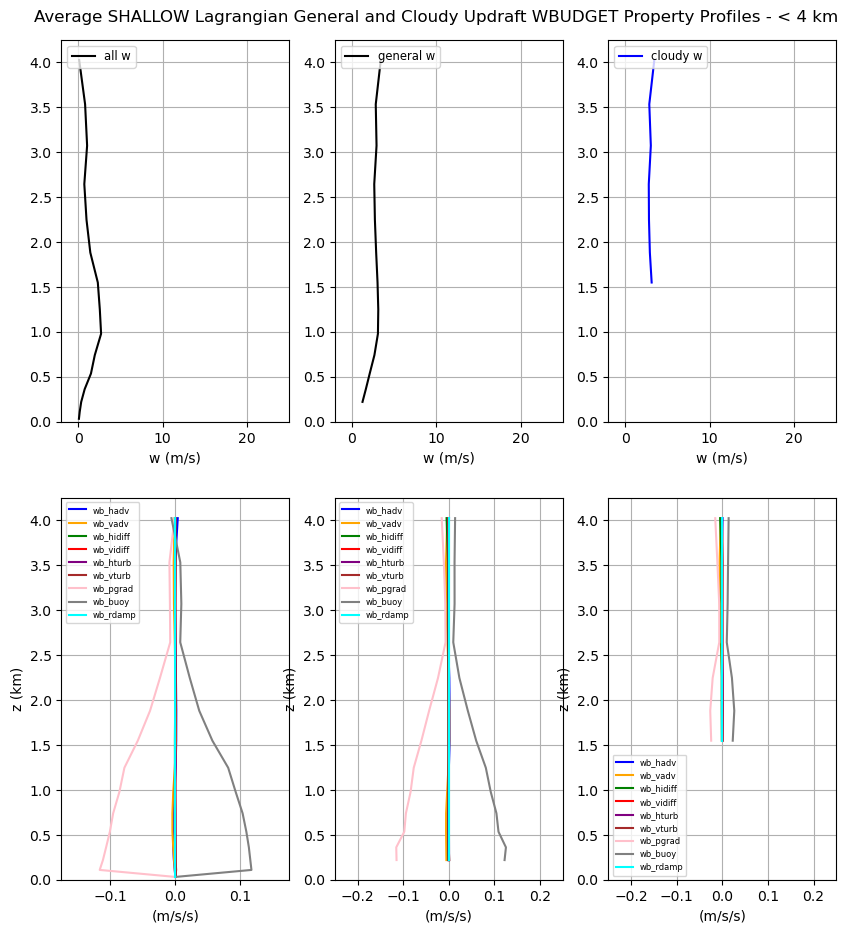

In [104]:
#W BUDGETS

convectivelevel=4

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(10, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"Average SHALLOW Lagrangian General and Cloudy Updraft WBUDGET Property Profiles - < {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","general","cloudy"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'tracking_algorithms/plots/job_out/shallow_WBUDGET_profile_{convectivelevel}km_all_wthresh{w_thresh}-.h5' #- Limited
        elif type=='general':
            input_file=dir+f'tracking_algorithms/plots/job_out/shallow_WBUDGET_profile_{convectivelevel}km_general_wthresh{w_thresh}-.h5'
        elif type=='cloudy':
            input_file=dir+f'tracking_algorithms/plots/job_out/shallow_WBUDGET_profile_{convectivelevel}km_cloudy_wthresh{w_thresh}-.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_rdamp = np.array(f['profile_wb_rdamp'])  # w budget: Rayleigh damper
        profile_wb_buoy = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy',
    'wb_rdamp'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis.set_xlim(-2,25)
        axis=ax4
    if type=='general':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis.set_xlim(-2,25)
        axis=ax5
    if type=='cloudy':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[1])
        axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis.set_xlim(-2,25)
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['all','general']:
            axis.legend(loc='upper left', fontsize=6); #add legend
        elif type in ['cloudy']:
            axis.legend(loc='lower left', fontsize=6); #add legend

        if type=='all':
            axis.set_xlim(left=-0.175,right=0.175)
        elif type=='general':
            axis.set_xlim(left=-0.25,right=0.25)
        elif type=='cloudy':
            axis.set_xlim(left=-0.25,right=0.25)
#save plot
if dim=='1km':
    plt.savefig(dir+f'tracking_algorithms/plots/1km_SHALLOW_eulerian_generalvscloudy_updraft_WBUDGET_profile_wthresh{w_thresh}-.jpg', bbox_inches='tight', dpi=300) 
#- Limited

In [8]:
#Shallow Parcels Lagrangian Parcels Profile (OPTIMIZED) 

#QV Budgets

#Making vertical profile of cloudy updrafts
print('loading neccessary variables')
if 'emptylike' not in globals():
    #Full Variables (W, QV, QC, QI)
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qv data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qi data
    qc_plus_qi=qc_data+qi_data
    emptylike=True
    
#QV Budget Variables
variable='qvb_hadv'; one_data=data[variable].data #'qv budget: horizontal advection (non-diff component)'
variable='qvb_vadv'; two_data=data[variable].data #'qv budget: vertical advection (non-diff component)'
variable='qvb_hidiff'; three_data=data[variable].data #'qv budget: horiz implicit diffusion'
variable='qvb_vidiff'; four_data=data[variable].data #'qv budget: vert implicit diffusion'
variable='qvb_hturb'; five_data=data[variable].data #'qv budget: horizontal parameterized turbulence'
variable='qvb_vturb'; six_data=data[variable].data #'qv budget: vertical parameterized turbulence'
variable='qvb_mp'; seven_data=data[variable].data #'qv budget: microphysics scheme'

# #QV Tendency Variables
# variable='qt_cond'; eight_data=data[variable].data #'qv tendency: condensation'
# variable='qt_evac'; nine_data=data[variable].data #'qv tendency: cloudwater evaporation'
# variable='qt_evar'; ten_data=data[variable].data #'qv tendency: rainwater evaporation'
print('done loading')


types=['all','general','cloudy']
vars = [
    'qv',
    'qvb_hadv',
    'qvb_vadv',
    'qvb_hidiff',
    'qvb_vidiff',
    'qvb_hturb',
    'qvb_vturb',
    'qvb_mp'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    global all_thresh,w_thresh,qcqi_thresh
    all_thresh=-1e6
    w_thresh=1 #m/s
    qcqi_thresh=1e-6 #kg/kg
   
    
    #create profile array
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    # position=(which_t.flatten(), which_z.flatten(), which_y.values.flatten(), which_x.values.flatten())
    lagrangian_w=w_data[position]
    lagrangian_qcplusqi=qc_plus_qi[position]
    
    for var in vars:
        print(f"variable {var}")
        if var=='qv':
            lagrangian_var=qv_data[position]
        elif var=='qvb_hadv':
            lagrangian_var=one_data[position]
        elif var=='qvb_vadv':
            lagrangian_var=two_data[position] 
        elif var=='qvb_hidiff':
            lagrangian_var=three_data[position]
        elif var=='qvb_vidiff':
            lagrangian_var=four_data[position] 
        elif var=='qvb_hturb':
            lagrangian_var=five_data[position]
        elif var=='qvb_vturb':
            lagrangian_var=six_data[position] 
        elif var=='qvb_mb':
            lagrangian_var=seven_data[position]
              
        #if w_zdata greater than threshold, add to profile z column and add count
        if type=='all':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=shallow_z.flatten()[np.where(lagrangian_w>=all_thresh)]
        elif type=='general':
            masked_var=lagrangian_var[np.where(lagrangian_w>=w_thresh)]
            masked_z=shallow_z.flatten()[np.where(lagrangian_w>=w_thresh)]
        elif type=='cloudy':
            masked_var=lagrangian_var[np.where((lagrangian_w>=w_thresh)&(lagrangian_qcplusqi>=qcqi_thresh))]
            masked_z=shallow_z.flatten()[np.where((lagrangian_w>=w_thresh)&(lagrangian_qcplusqi>=qcqi_thresh))]
        
            
        for count,(kh,value) in enumerate(zip(masked_z,masked_var)):
            # if np.mod(count,200)==0: print(f"{np.round(count*100/len(masked_z),1)}% done")
            globals()[f"profile_{var}"][kh,0]+=value #adds data to first column
            globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column
    
    if type=='all':
        output_file=dir+f'tracking_algorithms/plots/job_out/shallow_QVBUDGET_profile_{convectivelevel}km_all_wthresh{w_thresh}-.h5' #- Limited
    elif type=='general':
        output_file=dir+f'tracking_algorithms/plots/job_out/shallow_QVBUDGET_profile_{convectivelevel}km_general_wthresh{w_thresh}-.h5'
    elif type=='cloudy':
        output_file=dir+f'tracking_algorithms/plots/job_out/shallow_QVBUDGET_profile_{convectivelevel}km_cloudy_wthresh{w_thresh}-.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
        f.create_dataset('profile_qvb_hadv', data=profile_qvb_hadv, compression="gzip")
        f.create_dataset('profile_qvb_vadv', data=profile_qvb_vadv, compression="gzip")
        f.create_dataset('profile_qvb_hidiff', data=profile_qvb_hidiff, compression="gzip")
        f.create_dataset('profile_qvb_vidiff', data=profile_qvb_vidiff, compression="gzip")
        f.create_dataset('profile_qvb_hturb', data=profile_qvb_hturb, compression="gzip")
        f.create_dataset('profile_qvb_vturb', data=profile_qvb_vturb, compression="gzip")
        f.create_dataset('profile_qvb_mp', data=profile_qvb_mp, compression="gzip")
    print('done')

loading neccessary variables
done loading
type all
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done
type general
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done
type cloudy
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done


currently on type all
currently on type general
currently on type cloudy


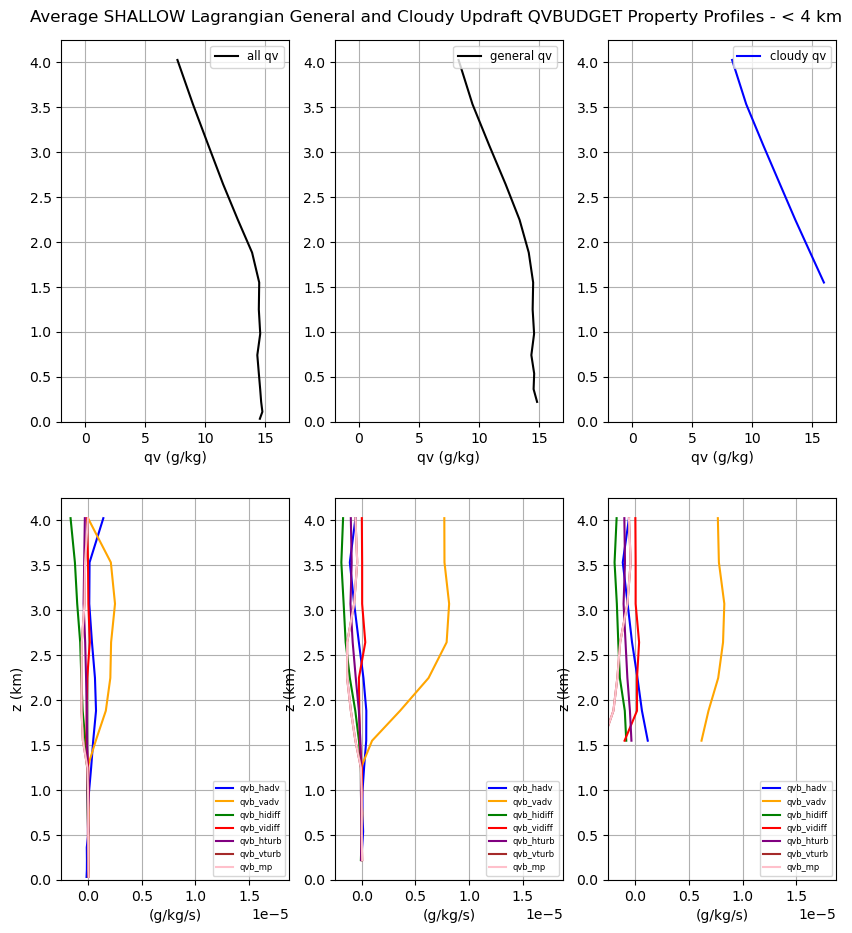

In [106]:
#QV BUDGETS #*******CURRENT

convectivelevel=4

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(10, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"Average SHALLOW Lagrangian General and Cloudy Updraft QVBUDGET Property Profiles - < {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","general","cloudy"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'tracking_algorithms/plots/job_out/shallow_QVBUDGET_profile_{convectivelevel}km_all_wthresh{w_thresh}-.h5' #- Limited
        elif type=='general':
            input_file=dir+f'tracking_algorithms/plots/job_out/shallow_QVBUDGET_profile_{convectivelevel}km_general_wthresh{w_thresh}-.h5'
        elif type=='cloudy':
            input_file=dir+f'tracking_algorithms/plots/job_out/shallow_QVBUDGET_profile_{convectivelevel}km_cloudy_wthresh{w_thresh}-.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
    out_qv[:,0]*=1000

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis.set_xlim(-2,17)
        
        axis=ax4
    if type=='general':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis.set_xlim(-2,17)
        axis=ax5
    if type=='cloudy':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[1])
        axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis.set_xlim(-2,17)
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type in ['all','general']:
            axis.legend(loc='lower right', fontsize=6); #add legend
        elif type in ['cloudy']:
            axis.legend(loc='lower right', fontsize=6); #add legend

        if type=='all':
            axis.set_xlim(left=(-0.25)*1e-5,right=(1.5+0.75*0.5)*1e-5)
        elif type=='general':
            axis.set_xlim(left=(-0.25)*1e-5,right=(1.5+0.75*0.5)*1e-5)
        elif type=='cloudy':
            axis.set_xlim(left=(-0.25)*1e-5,right=(1.5+0.75*0.5)*1e-5)
            
#save plot
if dim=='1km':
    plt.savefig(dir+f'tracking_algorithms/plots/1km_SHALLOW_eulerian_generalvscloudy_updraft_QVBUDGET_profile_wthresh{w_thresh}-.jpg', bbox_inches='tight', dpi=300) 

#- Limited

In [ ]:
################################################
# CL vs nonCL

In [1]:
#ALL Convective Parcels Profile
##### viewing tracking algorithm results
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.colors as colors
# import matplotlib.ticker as ticker
# import matplotlib.cm as cm
# from matplotlib.colors import Normalize
# import matplotlib.gridspec as gridspec
# import xarray as xr
# import os; import time
# import h5py

# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/Project/'
# data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# parcel=xr.open_dataset(dir+'cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# whereCL=xr.open_dataset(dir+'tracking_algorithms/whereCL_4_0622.nc').load() #***
# whereCL=whereCL.isel(time=slice(0,len(data['time'])))

In [57]:
#OUT_NZ

# out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_combined.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_combined.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

out_nz=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_nz[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_nz[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_nz[:,0] == elem)[0] 
    extras=idx[np.where(out_nz[idx,5]!=np.min(out_nz[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_nz), dtype=bool); mask[lst] = False
out_nz=out_nz[mask]; 

###############################################################################

out_nz=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];print('list of first 10 ignored parcels');print(save_nz[:5])
placeholder=out_nz.copy(); run=True
#################################################################
print(f'there are a total of {len(out_nz)} SBZ parcels and {len(save_nz)} forgotten parcels')


list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
list of first 10 ignored parcels
[[34 302 76 0.7418956298828125 34 37]
 [246 338 77 0.33685012817382814 2 11]
 [365 357 3 0.658669677734375 115 121]
 [363 440 62 0.18019241333007813 6 14]
 [483 465 43 0.2835696716308594 27 33]]
there are a total of 2088 SBZ parcels and 1717 forgotten parcels


In [58]:
def grid_location(x,y,z):
    xf=data['xf'].values*1000; which_xh=np.searchsorted(xf,x)-1; which_xh=np.where(which_xh == -1, 0, which_xh) #finds which x layer parcel in
    yf=data['yf'].values*1000; which_yh=np.searchsorted(yf,y)-1; which_yh=np.where(which_yh == -1, 0, which_yh) #finds which y layer parcel in
    zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in     
    return which_zh,which_yh,which_xh

x=parcel['x'];y=parcel['y'];z=parcel['z']
which_z,which_y,which_x=grid_location(x,y,z)

#Makes np.where style mask for CL parcel locations
######################################################

#Setting up run for CL convective parcels
# np.arange(Np)==>out_nz[:,0]
# np.arange(Nt)==>out_nz[:,4]
col4 = out_nz[:, 4].astype(int)
# col5 = out_nz[:, 5].astype(int)
col5 = out_nz[:, 5].astype(int) + 2 #add another 10 minutes to each trajectory
ranges = [np.arange(start, end + 1) for start, end in zip(col4, col5)]
indexes = out_nz[:,0]
indexranges = [np.full_like(r, fill_value=index) for r, index in zip(ranges, indexes)]
totalelements=sum(len(arr) for arr in ranges)
print(f'running for total of {totalelements} elements')


CL_t,CL_z,CL_y,CL_x=[],[],[],[]
for R in np.arange(len(ranges)):
    tup=(ranges[R],indexranges[R])
    CL_t.extend(ranges[R])
    CL_z.extend(which_z[tup])
    CL_y.extend(which_y[tup])
    CL_x.extend(which_x[tup])
CL_t=np.array(CL_t);CL_z=np.array(CL_z);CL_y=np.array(CL_y);CL_x=np.array(CL_x)
CLposition=(CL_t, CL_z, CL_y, CL_x)
print('done')

#####################################################################################

#Makes np.where style mask for nonCL parcel locations
######################################################
out_nz=save_nz.copy() #out_nz is actually save_nz for code below

#Setting up run for nonCL convective parcels
# np.arange(Np)==>out_nz[:,0]
# np.arange(Nt)==>out_nz[:,4]
col4 = out_nz[:, 4].astype(int)
# col5 = out_nz[:, 5].astype(int)
col5 = out_nz[:, 5].astype(int) + 2 #add another 10 minutes to each trajectory
ranges = [np.arange(start, end + 1) for start, end in zip(col4, col5)]
indexes = out_nz[:,0]
indexranges = [np.full_like(r, fill_value=index) for r, index in zip(ranges, indexes)]
totalelements=sum(len(arr) for arr in ranges)
print(f'running for total of {totalelements} elements')


nonCL_t,nonCL_z,nonCL_y,nonCL_x=[],[],[],[]
for R in np.arange(len(ranges)):
    tup=(ranges[R],indexranges[R])
    nonCL_t.extend(ranges[R])
    nonCL_z.extend(which_z[tup])
    nonCL_y.extend(which_y[tup])
    nonCL_x.extend(which_x[tup])
nonCL_t=np.array(nonCL_t);nonCL_z=np.array(nonCL_z);nonCL_y=np.array(nonCL_y);nonCL_x=np.array(nonCL_x)
nonCLposition=(nonCL_t, nonCL_z, nonCL_y, nonCL_x)
print('done')

running for total of 17364 elements
done
running for total of 14509 elements
done


In [59]:
#CL vs nonCL Parcels Lagrangian Parcels Profile (OPTIMIZED) 

#W Budgets

#Making vertical profile of cloudy updrafts
print('loading neccessary variables')
if 'emptylike' not in globals():

    #Full Variables (W, QV, QC, QI)
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qv data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qi data
    qc_plus_qi=qc_data+qi_data
    emptylike=True
    
#W Budget Variables
variable='wb_hadv'; one_data=data[variable].data #'w budget: horizontal advection (non-diff component)'
variable='wb_vadv'; two_data=data[variable].data #'w budget: vertical advection (non-diff component)'
variable='wb_hidiff'; three_data=data[variable].data #'w budget: horiz implicit diffusion'
variable='wb_vidiff'; four_data=data[variable].data #'w budget: vert implicit diffusion'
variable='wb_hturb'; five_data=data[variable].data #'w budget: horizontal parameterized turbulence'
variable='wb_vturb'; six_data=data[variable].data #'w budget: vertical parameterized turbulence'
variable='wb_pgrad'; seven_data=data[variable].data #'w budget: pressure gradient'
variable='wb_rdamp'; eight_data=data[variable].data #'w budget: Rayleigh damper'
variable='wb_buoy'; nine_data=data[variable].data #'w budget: buoyancy'
print('done loading')


types=['CL','nonCL']
vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_rdamp',
    'wb_buoy'
]
for type in types:
    print(f"type {type}")
    if type=='CL':
        position=CLposition
    elif type=='nonCL':
        position=nonCLposition

    # #creates profile storage and adds z column  
    global all_thresh
    all_thresh=-1e6
   
    
    #create profile array
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    # position=(which_t.flatten(), which_z.flatten(), which_y.values.flatten(), which_x.values.flatten())
    lagrangian_w=w_data[position]
    lagrangian_qcplusqi=qc_plus_qi[position]
    
    for var in vars:
        print(f"variable {var}")
        if var=='w':
            lagrangian_var=w_data[position]
        elif var=='wb_hadv':
            lagrangian_var=one_data[position]
        elif var=='wb_vadv':
            lagrangian_var=two_data[position] 
        elif var=='wb_hidiff':
            lagrangian_var=three_data[position]
        elif var=='wb_vidiff':
            lagrangian_var=four_data[position] 
        elif var=='wb_hturb':
            lagrangian_var=five_data[position]
        elif var=='wb_vturb':
            lagrangian_var=six_data[position] 
        elif var=='wb_pgrad':
            lagrangian_var=seven_data[position]
        elif var=='wb_rdamp':
            lagrangian_var=eight_data[position] 
        elif var=='wb_buoy':
            lagrangian_var=nine_data[position] 

              
        #if w_zdata greater than threshold, add to profile z column and add count
        if type=='CL':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=CL_z.flatten()[np.where(lagrangian_w>=all_thresh)]
        elif type=='nonCL':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=nonCL_z.flatten()[np.where(lagrangian_w>=all_thresh)]
        
        
            
        for count,(kh,value) in enumerate(zip(masked_z,masked_var)):
            # if np.mod(count,200)==0: print(f"{np.round(count*100/len(masked_z),1)}% done")
            globals()[f"profile_{var}"][kh,0]+=value #adds data to first column
            globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column
    
    if type=='CL':
        output_file=dir+f'tracking_algorithms/plots/job_out/CL_lagrangian_WBUDGET_profile.h5'
    elif type=='nonCL':
        output_file=dir+f'tracking_algorithms/plots/job_out/nonCL_lagrangian_WBUDGET_profile.h5'
        
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_w', data=profile_w, compression="gzip")
        f.create_dataset('profile_wb_hadv', data=profile_wb_hadv, compression="gzip")
        f.create_dataset('profile_wb_vadv', data=profile_wb_vadv, compression="gzip")
        f.create_dataset('profile_wb_hidiff', data=profile_wb_hidiff, compression="gzip")
        f.create_dataset('profile_wb_vidiff', data=profile_wb_vidiff, compression="gzip")
        f.create_dataset('profile_wb_hturb', data=profile_wb_hturb, compression="gzip")
        f.create_dataset('profile_wb_vturb', data=profile_wb_vturb, compression="gzip")
        f.create_dataset('profile_wb_pgrad', data=profile_wb_pgrad, compression="gzip")
        f.create_dataset('profile_wb_rdamp', data=profile_wb_rdamp, compression="gzip")
        f.create_dataset('profile_wb_buoy', data=profile_wb_buoy, compression="gzip")
    print('done')

loading neccessary variables
done loading
type CL
variable w
variable wb_hadv
variable wb_vadv
variable wb_hidiff
variable wb_vidiff
variable wb_hturb
variable wb_vturb
variable wb_pgrad
variable wb_rdamp
variable wb_buoy
done
type nonCL
variable w
variable wb_hadv
variable wb_vadv
variable wb_hidiff
variable wb_vidiff
variable wb_hturb
variable wb_vturb
variable wb_pgrad
variable wb_rdamp
variable wb_buoy
done


currently on type CL
currently on type nonCL


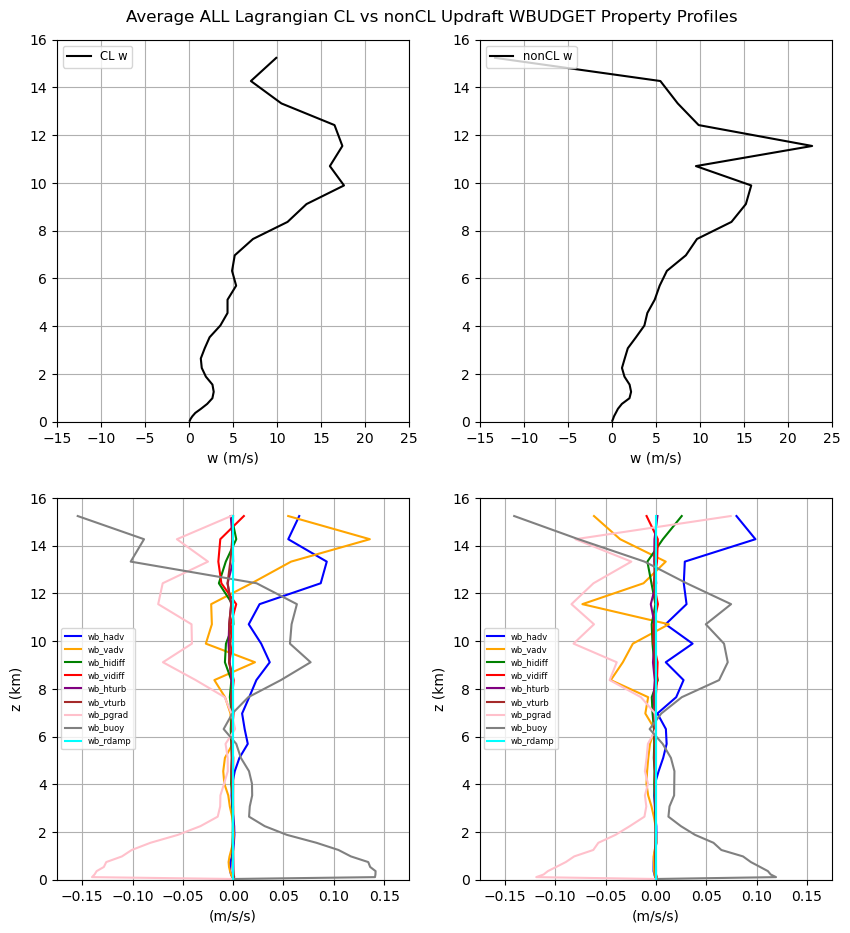

In [42]:
#W BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"Average ALL Lagrangian CL vs nonCL Updraft WBUDGET Property Profiles")
ax1, ax2, ax3, ax4 = axs.flatten()

####################################################################
for type in ["CL","nonCL"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='CL':
            input_file=dir+f'tracking_algorithms/plots/job_out/CL_lagrangian_WBUDGET_profile.h5'
        elif type=='nonCL':
            input_file=dir+f'tracking_algorithms/plots/job_out/nonCL_lagrangian_WBUDGET_profile.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_rdamp = np.array(f['profile_wb_rdamp'])  # w budget: Rayleigh damper
        profile_wb_buoy = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy',
    'wb_rdamp'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='CL':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis.set_xlim(-15,25)

    if type=='nonCL':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis.set_xlim(-15,25)

    if type=='CL':
        for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
            axis=ax3
            plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
            axis.set_ylim(bottom=0,top=16)
            axis.set_ylabel('z (km)');
            axis.set_xlabel('(m/s/s)')
            axis.legend(loc='center left', fontsize=6); #add legend
            
    if type=='nonCL':
        for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
            axis=ax4
            plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
            axis.set_ylim(bottom=0,top=16)
            axis.set_ylabel('z (km)');
            axis.set_xlabel('(m/s/s)')
            axis.legend(loc='center left', fontsize=6); #add legend

    if type=='CL':
        axis.set_xlim(left=(-0.15-0.5*0.05),right=(0.15+0.5*0.05))
    elif type=='nonCL':
        axis.set_xlim(left=(-0.15-0.5*0.05),right=(0.15+0.5*0.05))
#save plot
if dim=='1km':
    plt.savefig(dir+f'tracking_algorithms/plots/CLvsnonCL_lagrangian_WBUDGET_ALL_profile.jpg', bbox_inches='tight', dpi=300) 


In [ ]:
#################################

In [61]:
#CL vs nonCL Parcels Lagrangian Parcels Profile (OPTIMIZED) 

#QV Budgets

#Making vertical profile of cloudy updrafts
print('loading neccessary variables')
if 'emptylike' not in globals():

    #Full Variables (W, QV, QC, QI)
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qv data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qi data
    qc_plus_qi=qc_data+qi_data
    emptylike=True
    
#W Budget Variables
variable='qvb_hadv'; one_data=data[variable].data #'w budget: horizontal advection (non-diff component)'
variable='qvb_vadv'; two_data=data[variable].data #'w budget: vertical advection (non-diff component)'
variable='qvb_hidiff'; three_data=data[variable].data #'w budget: horiz implicit diffusion'
variable='qvb_vidiff'; four_data=data[variable].data #'w budget: vert implicit diffusion'
variable='qvb_hturb'; five_data=data[variable].data #'w budget: horizontal parameterized turbulence'
variable='qvb_vturb'; six_data=data[variable].data #'w budget: vertical parameterized turbulence'
variable='qvb_mp'; seven_data=data[variable].data #'w budget: pressure gradient'
print('done loading')


types=['CL','nonCL']
vars = [
    'qv',
    'qvb_hadv',
    'qvb_vadv',
    'qvb_hidiff',
    'qvb_vidiff',
    'qvb_hturb',
    'qvb_vturb',
    'qvb_mp'
]
for type in types:
    print(f"type {type}")
    if type=='CL':
        position=CLposition
    elif type=='nonCL':
        position=nonCLposition

    # #creates profile storage and adds z column  
    global all_thresh
    all_thresh=-1e6
   
    
    #create profile array
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    # position=(which_t.flatten(), which_z.flatten(), which_y.values.flatten(), which_x.values.flatten())
    lagrangian_w=w_data[position]
    lagrangian_qcplusqi=qc_plus_qi[position]
    
    for var in vars:
        print(f"variable {var}")
        if var=='qv':
            lagrangian_var=qv_data[position]
        elif var=='qvb_hadv':
            lagrangian_var=one_data[position]
        elif var=='qvb_vadv':
            lagrangian_var=two_data[position] 
        elif var=='qvb_hidiff':
            lagrangian_var=three_data[position]
        elif var=='qvb_vidiff':
            lagrangian_var=four_data[position] 
        elif var=='qvb_hturb':
            lagrangian_var=five_data[position]
        elif var=='qvb_vturb':
            lagrangian_var=six_data[position] 
        elif var=='qvb_mp':
            lagrangian_var=seven_data[position]

              
        #if w_zdata greater than threshold, add to profile z column and add count
        if type=='CL':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=CL_z.flatten()[np.where(lagrangian_w>=all_thresh)]
        elif type=='nonCL':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=nonCL_z.flatten()[np.where(lagrangian_w>=all_thresh)]
        
            
        for count,(kh,value) in enumerate(zip(masked_z,masked_var)):
            # if np.mod(count,200)==0: print(f"{np.round(count*100/len(masked_z),1)}% done")
            globals()[f"profile_{var}"][kh,0]+=value #adds data to first column
            globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column
    
    if type=='CL':
        output_file=dir+f'tracking_algorithms/plots/job_out/CL_lagrangian_QVBUDGET_profile.h5'
    elif type=='nonCL':
        output_file=dir+f'tracking_algorithms/plots/job_out/nonCL_lagrangian_QVBUDGET_profile.h5'
        
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
        f.create_dataset('profile_qvb_hadv', data=profile_qvb_hadv, compression="gzip")
        f.create_dataset('profile_qvb_vadv', data=profile_qvb_vadv, compression="gzip")
        f.create_dataset('profile_qvb_hidiff', data=profile_qvb_hidiff, compression="gzip")
        f.create_dataset('profile_qvb_vidiff', data=profile_qvb_vidiff, compression="gzip")
        f.create_dataset('profile_qvb_hturb', data=profile_qvb_hturb, compression="gzip")
        f.create_dataset('profile_qvb_vturb', data=profile_qvb_vturb, compression="gzip")
        f.create_dataset('profile_qvb_mp', data=profile_qvb_mp, compression="gzip")
    print('done')

loading neccessary variables
done loading
type CL
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done
type nonCL
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done


currently on type CL
currently on type nonCL


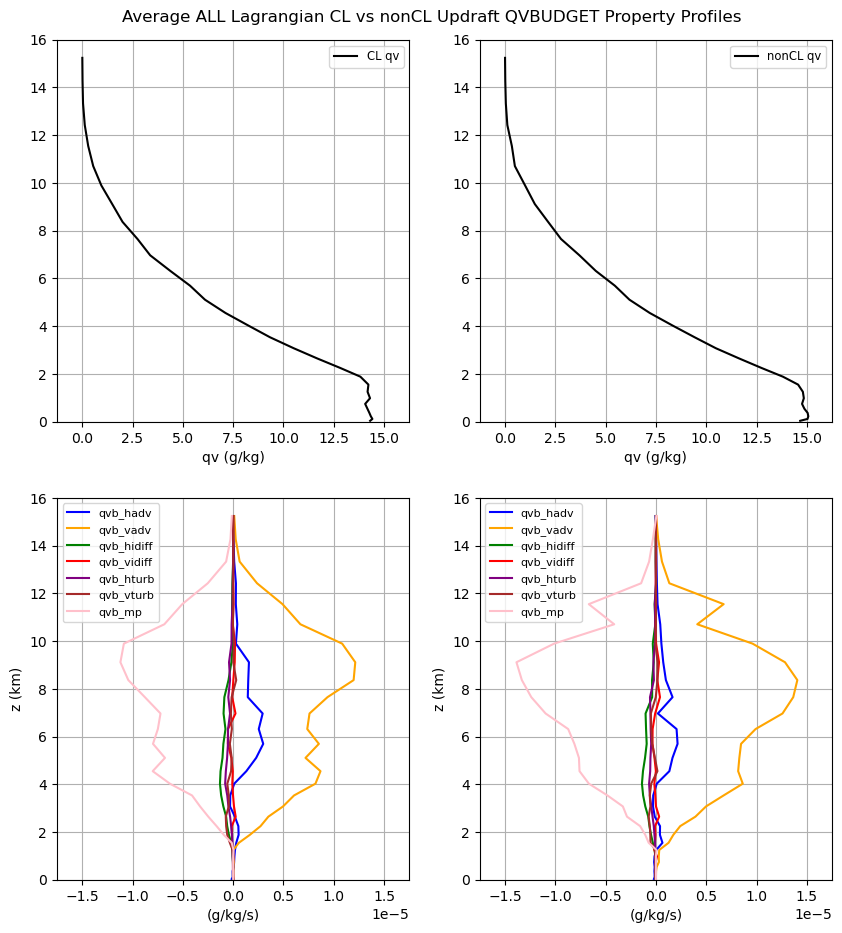

In [65]:
#QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"Average ALL Lagrangian CL vs nonCL Updraft QVBUDGET Property Profiles")
ax1, ax2, ax3, ax4 = axs.flatten()

####################################################################
for type in ["CL","nonCL"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='CL':
            input_file=dir+f'tracking_algorithms/plots/job_out/CL_lagrangian_QVBUDGET_profile.h5'
        elif type=='nonCL':
            input_file=dir+f'tracking_algorithms/plots/job_out/nonCL_lagrangian_QVBUDGET_profile.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
    out_qv[:,0]*=1000

    if type=='CL':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis.set_xlim(left=(0-0.5*2.5),right=(15+0.5*2.5))

    if type=='nonCL':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis.set_xlim(left=(0-0.5*2.5),right=(15+0.5*2.5))

    if type=='CL':
        for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
            axis=ax3
            plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
            axis.set_ylim(bottom=0,top=16)
            axis.set_ylabel('z (km)');
            axis.set_xlabel('(g/kg/s)')
            axis.legend(loc='upper left', fontsize=8); #add legend
            
    if type=='nonCL':
        for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
            axis=ax4
            plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
            axis.set_ylim(bottom=0,top=16)
            axis.set_ylabel('z (km)');
            axis.set_xlabel('(g/kg/s)')
            axis.legend(loc='upper left', fontsize=8); #add legend

    if type=='CL':
        axis.set_xlim(left=(-1.5-0.5*0.5)*1e-5,right=(1.5+0.5*0.5)*1e-5)
    elif type=='nonCL':
        axis.set_xlim(left=(-1.5-0.5*0.5)*1e-5,right=(1.5+0.5*0.5)*1e-5)


    # ax1.set_ylim((0,2))
    # ax2.set_ylim((0,2))
    # ax3.set_ylim((0,2))
    # ax4.set_ylim((0,2))

    # ax3.set_xlim((-0.5e-5,0.5e-5))
    # ax4.set_xlim((-0.5e-5,0.5e-5))
#save plot
if dim=='1km':
    plt.savefig(dir+f'tracking_algorithms/plots/CLvsnonCL_lagrangian_QVBUDGET_ALL_profile.jpg', bbox_inches='tight', dpi=300) 


In [ ]:
#DEEP

In [8]:
#ALL Convective Parcels Profile
##### viewing tracking algorithm results
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.colors as colors
# import matplotlib.ticker as ticker
# import matplotlib.cm as cm
# from matplotlib.colors import Normalize
# import matplotlib.gridspec as gridspec
# import xarray as xr
# import os; import time
# import h5py

# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/Project/'
# data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# parcel=xr.open_dataset(dir+'cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# whereCL=xr.open_dataset(dir+'tracking_algorithms/whereCL_4_0622.nc').load() #***
# whereCL=whereCL.isel(time=slice(0,len(data['time'])))

In [63]:
#OUT_NZ

# out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***


out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_combined.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_combined.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

out_nz=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_nz[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_nz[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_nz[:,0] == elem)[0] 
    extras=idx[np.where(out_nz[idx,5]!=np.min(out_nz[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_nz), dtype=bool); mask[lst] = False
out_nz=out_nz[mask]; 

###############################################################################

out_nz=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];print('list of first 10 ignored parcels');print(save_nz[:5])
placeholder1=out_nz.copy(); run=True
placeholder2=save_nz.copy(); run=True
# print(f'there are a total of {len(out_nz)} SBZ parcels and {len(save_nz)} forgotten parcels')

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def threshold_out(zthresh):
    out_nz=placeholder1.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>zthresh):
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz, extendrange
    # print(out_nz)
##############################################################
def threshold_save(zthresh):
    save_nz=placeholder2.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(save_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(save_nz[ind,5],save_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=save_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>zthresh):
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    save_nz=save_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(save_nz)} leftover parcels')
    return save_nz, extendrange
    # print(save_nz)
##############################################################

convectivelevel=6 #6km
[out_nz,extendrange]=threshold_out(convectivelevel)
[save_nz,extendrange]=threshold_save(convectivelevel)

print('list of first 10 SBZ parcels'); print(out_nz[:15])
print(f'there are a total of {len(out_nz)} CL parcels and {len(save_nz)} non-CL parcels')

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
list of first 10 ignored parcels
[[34 302 76 0.7418956298828125 34 37]
 [246 338 77 0.33685012817382814 2 11]
 [365 357 3 0.658669677734375 115 121]
 [363 440 62 0.18019241333007813 6 14]
 [483 465 43 0.2835696716308594 27 33]]
list of first 10 SBZ parcels
[[452 334 53 0.1520338897705078 43 48]
 [704 374 63 0.24067965698242189 57 62]
 [885 300 10 0.11673685455322266 59 65]
 [1022 37

In [64]:
def grid_location(x,y,z):
    xf=data['xf'].values*1000; which_xh=np.searchsorted(xf,x)-1; which_xh=np.where(which_xh == -1, 0, which_xh) #finds which x layer parcel in
    yf=data['yf'].values*1000; which_yh=np.searchsorted(yf,y)-1; which_yh=np.where(which_yh == -1, 0, which_yh) #finds which y layer parcel in
    zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in     
    return which_zh,which_yh,which_xh

x=parcel['x'];y=parcel['y'];z=parcel['z']
which_z,which_y,which_x=grid_location(x,y,z)

#Makes np.where style mask for CL parcel locations
######################################################

#Setting up run for CL convective parcels
# np.arange(Np)==>out_nz[:,0]
# np.arange(Nt)==>out_nz[:,4]
col4 = out_nz[:, 4].astype(int)
# col5 = out_nz[:, 5].astype(int)
col5 = out_nz[:, 5].astype(int) + 2 #add another 10 minutes to each trajectory
ranges = [np.arange(start, end + 1) for start, end in zip(col4, col5)]
indexes = out_nz[:,0]
indexranges = [np.full_like(r, fill_value=index) for r, index in zip(ranges, indexes)]
totalelements=sum(len(arr) for arr in ranges)
print(f'running for total of {totalelements} elements')


CL_t,CL_z,CL_y,CL_x=[],[],[],[]
for R in np.arange(len(ranges)):
    tup=(ranges[R],indexranges[R])
    CL_t.extend(ranges[R])
    CL_z.extend(which_z[tup])
    CL_y.extend(which_y[tup])
    CL_x.extend(which_x[tup])
CL_t=np.array(CL_t);CL_z=np.array(CL_z);CL_y=np.array(CL_y);CL_x=np.array(CL_x)
CLposition=(CL_t, CL_z, CL_y, CL_x)
print('done')

#####################################################################################

#Makes np.where style mask for nonCL parcel locations
######################################################
out_nz=save_nz.copy() #out_nz is actually save_nz for code below

#Setting up run for nonCL convective parcels
# np.arange(Np)==>out_nz[:,0]
# np.arange(Nt)==>out_nz[:,4]
col4 = out_nz[:, 4].astype(int)
# col5 = out_nz[:, 5].astype(int)
col5 = out_nz[:, 5].astype(int) + 2 #add another 10 minutes to each trajectory
ranges = [np.arange(start, end + 1) for start, end in zip(col4, col5)]
indexes = out_nz[:,0]
indexranges = [np.full_like(r, fill_value=index) for r, index in zip(ranges, indexes)]
totalelements=sum(len(arr) for arr in ranges)
print(f'running for total of {totalelements} elements')


nonCL_t,nonCL_z,nonCL_y,nonCL_x=[],[],[],[]
for R in np.arange(len(ranges)):
    tup=(ranges[R],indexranges[R])
    nonCL_t.extend(ranges[R])
    nonCL_z.extend(which_z[tup])
    nonCL_y.extend(which_y[tup])
    nonCL_x.extend(which_x[tup])
nonCL_t=np.array(nonCL_t);nonCL_z=np.array(nonCL_z);nonCL_y=np.array(nonCL_y);nonCL_x=np.array(nonCL_x)
nonCLposition=(nonCL_t, nonCL_z, nonCL_y, nonCL_x)
print('done')

running for total of 3118 elements
done
running for total of 2672 elements
done


In [65]:
#CL vs nonCL Parcels Lagrangian Parcels Profile (OPTIMIZED) 

#W Budgets

#Making vertical profile of cloudy updrafts
print('loading neccessary variables')
if 'emptylike' not in globals():

    #Full Variables (W, QV, QC, QI)
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qv data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qi data
    qc_plus_qi=qc_data+qi_data
    emptylike=True
    
#W Budget Variables
variable='wb_hadv'; one_data=data[variable].data #'w budget: horizontal advection (non-diff component)'
variable='wb_vadv'; two_data=data[variable].data #'w budget: vertical advection (non-diff component)'
variable='wb_hidiff'; three_data=data[variable].data #'w budget: horiz implicit diffusion'
variable='wb_vidiff'; four_data=data[variable].data #'w budget: vert implicit diffusion'
variable='wb_hturb'; five_data=data[variable].data #'w budget: horizontal parameterized turbulence'
variable='wb_vturb'; six_data=data[variable].data #'w budget: vertical parameterized turbulence'
variable='wb_pgrad'; seven_data=data[variable].data #'w budget: pressure gradient'
variable='wb_rdamp'; eight_data=data[variable].data #'w budget: Rayleigh damper'
variable='wb_buoy'; nine_data=data[variable].data #'w budget: buoyancy'
print('done loading')


types=['CL','nonCL']
vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_rdamp',
    'wb_buoy'
]
for type in types:
    print(f"type {type}")
    if type=='CL':
        position=CLposition
    elif type=='nonCL':
        position=nonCLposition

    # #creates profile storage and adds z column  
    global all_thresh
    all_thresh=-1e6
   
    
    #create profile array
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    # position=(which_t.flatten(), which_z.flatten(), which_y.values.flatten(), which_x.values.flatten())
    lagrangian_w=w_data[position]
    lagrangian_qcplusqi=qc_plus_qi[position]
    
    for var in vars:
        print(f"variable {var}")
        if var=='w':
            lagrangian_var=w_data[position]
        elif var=='wb_hadv':
            lagrangian_var=one_data[position]
        elif var=='wb_vadv':
            lagrangian_var=two_data[position] 
        elif var=='wb_hidiff':
            lagrangian_var=three_data[position]
        elif var=='wb_vidiff':
            lagrangian_var=four_data[position] 
        elif var=='wb_hturb':
            lagrangian_var=five_data[position]
        elif var=='wb_vturb':
            lagrangian_var=six_data[position] 
        elif var=='wb_pgrad':
            lagrangian_var=seven_data[position]
        elif var=='wb_rdamp':
            lagrangian_var=eight_data[position] 
        elif var=='wb_buoy':
            lagrangian_var=nine_data[position] 

              
        #if w_zdata greater than threshold, add to profile z column and add count
        if type=='CL':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=CL_z.flatten()[np.where(lagrangian_w>=all_thresh)]
        elif type=='nonCL':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=nonCL_z.flatten()[np.where(lagrangian_w>=all_thresh)]
        
        
            
        for count,(kh,value) in enumerate(zip(masked_z,masked_var)):
            # if np.mod(count,200)==0: print(f"{np.round(count*100/len(masked_z),1)}% done")
            globals()[f"profile_{var}"][kh,0]+=value #adds data to first column
            globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column
    
    if type=='CL':
        output_file=dir+f'tracking_algorithms/plots/job_out/CL_lagrangian_WBUDGET_DEEP_profile.h5'
    elif type=='nonCL':
        output_file=dir+f'tracking_algorithms/plots/job_out/nonCL_lagrangian_WBUDGET_DEEP_profile.h5'
        
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_w', data=profile_w, compression="gzip")
        f.create_dataset('profile_wb_hadv', data=profile_wb_hadv, compression="gzip")
        f.create_dataset('profile_wb_vadv', data=profile_wb_vadv, compression="gzip")
        f.create_dataset('profile_wb_hidiff', data=profile_wb_hidiff, compression="gzip")
        f.create_dataset('profile_wb_vidiff', data=profile_wb_vidiff, compression="gzip")
        f.create_dataset('profile_wb_hturb', data=profile_wb_hturb, compression="gzip")
        f.create_dataset('profile_wb_vturb', data=profile_wb_vturb, compression="gzip")
        f.create_dataset('profile_wb_pgrad', data=profile_wb_pgrad, compression="gzip")
        f.create_dataset('profile_wb_rdamp', data=profile_wb_rdamp, compression="gzip")
        f.create_dataset('profile_wb_buoy', data=profile_wb_buoy, compression="gzip")
    print('done') 

loading neccessary variables
done loading
type CL
variable w
variable wb_hadv
variable wb_vadv
variable wb_hidiff
variable wb_vidiff
variable wb_hturb
variable wb_vturb
variable wb_pgrad
variable wb_rdamp
variable wb_buoy
done
type nonCL
variable w
variable wb_hadv
variable wb_vadv
variable wb_hidiff
variable wb_vidiff
variable wb_hturb
variable wb_vturb
variable wb_pgrad
variable wb_rdamp
variable wb_buoy
done


currently on type CL
currently on type nonCL


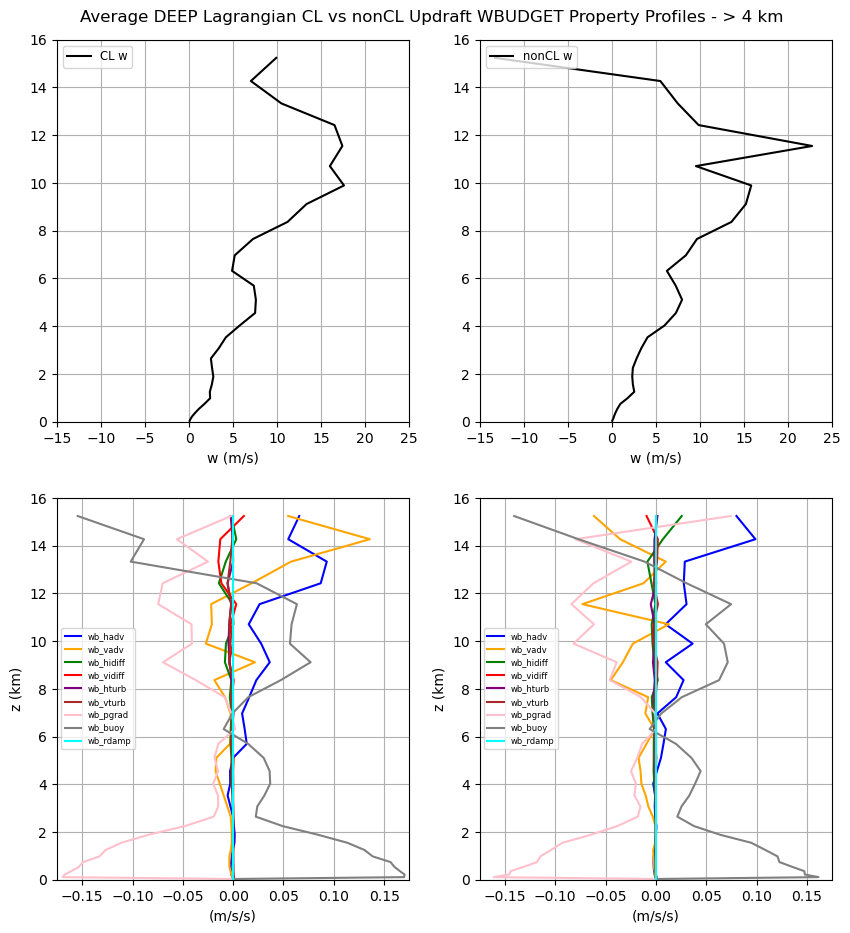

In [43]:
#W BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"Average DEEP Lagrangian CL vs nonCL Updraft WBUDGET Property Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4 = axs.flatten()

####################################################################
for type in ["CL","nonCL"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='CL':
            input_file=dir+f'tracking_algorithms/plots/job_out/CL_lagrangian_WBUDGET_DEEP_profile.h5'
        elif type=='nonCL':
            input_file=dir+f'tracking_algorithms/plots/job_out/nonCL_lagrangian_WBUDGET_DEEP_profile.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_rdamp = np.array(f['profile_wb_rdamp'])  # w budget: Rayleigh damper
        profile_wb_buoy = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy', #**********
    'wb_rdamp'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey', #*************
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='CL':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis.set_xlim(-15,25)

    if type=='nonCL':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis.set_xlim(-15,25)

    if type=='CL':
        for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
            axis=ax3
            plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
            axis.set_ylim(bottom=0,top=16)
            axis.set_ylabel('z (km)');
            axis.set_xlabel('(m/s/s)')
            axis.legend(loc='center left', fontsize=6); #add legend
            
    if type=='nonCL':
        for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
            axis=ax4
            plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
            axis.set_ylim(bottom=0,top=16)
            axis.set_ylabel('z (km)');
            axis.set_xlabel('(m/s/s)')
            axis.legend(loc='center left', fontsize=6); #add legend

    if type=='CL':
        axis.set_xlim(left=(-0.15-0.5*0.05),right=(0.15+0.5*0.05))
    elif type=='nonCL':
        axis.set_xlim(left=(-0.15-0.5*0.05),right=(0.15+0.5*0.05))
            
#save plot
if dim=='1km':
    plt.savefig(dir+f'tracking_algorithms/plots/CLvsnonCL_lagrangian_WBUDGET_DEEP_profile.jpg', bbox_inches='tight', dpi=300) 


In [67]:
#CL vs nonCL Parcels Lagrangian Parcels Profile (OPTIMIZED) 

#QV Budgets

#Making vertical profile of cloudy updrafts
print('loading neccessary variables')
if 'emptylike' not in globals():

    #Full Variables (W, QV, QC, QI)
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qv data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qi data
    qc_plus_qi=qc_data+qi_data
    emptylike=True
    
#QV Budget Variables
variable='qvb_hadv'; one_data=data[variable].data #'w budget: horizontal advection (non-diff component)'
variable='qvb_vadv'; two_data=data[variable].data #'w budget: vertical advection (non-diff component)'
variable='qvb_hidiff'; three_data=data[variable].data #'w budget: horiz implicit diffusion'
variable='qvb_vidiff'; four_data=data[variable].data #'w budget: vert implicit diffusion'
variable='qvb_hturb'; five_data=data[variable].data #'w budget: horizontal parameterized turbulence'
variable='qvb_vturb'; six_data=data[variable].data #'w budget: vertical parameterized turbulence'
variable='qvb_mp'; seven_data=data[variable].data #'w budget: pressure gradient'
print('done loading')

types=['CL','nonCL']
vars = [
    'qv',
    'qvb_hadv',
    'qvb_vadv',
    'qvb_hidiff',
    'qvb_vidiff',
    'qvb_hturb',
    'qvb_vturb',
    'qvb_mp'
]
for type in types:
    print(f"type {type}")
    if type=='CL':
        position=CLposition
    elif type=='nonCL':
        position=nonCLposition

    # #creates profile storage and adds z column  
    global all_thresh
    all_thresh=-1e6
   
    
    #create profile array
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    # position=(which_t.flatten(), which_z.flatten(), which_y.values.flatten(), which_x.values.flatten())
    lagrangian_w=w_data[position]
    lagrangian_qcplusqi=qc_plus_qi[position]
    
    for var in vars:
        print(f"variable {var}")
        if var=='qv':
            lagrangian_var=qv_data[position]
        elif var=='qvb_hadv':
            lagrangian_var=one_data[position]
        elif var=='qvb_vadv':
            lagrangian_var=two_data[position] 
        elif var=='qvb_hidiff':
            lagrangian_var=three_data[position]
        elif var=='qvb_vidiff':
            lagrangian_var=four_data[position] 
        elif var=='qvb_hturb':
            lagrangian_var=five_data[position]
        elif var=='qvb_vturb':
            lagrangian_var=six_data[position] 
        elif var=='qvb_mp':
            lagrangian_var=seven_data[position]

              
        #if w_zdata greater than threshold, add to profile z column and add count
        if type=='CL':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=CL_z.flatten()[np.where(lagrangian_w>=all_thresh)]
        elif type=='nonCL':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=nonCL_z.flatten()[np.where(lagrangian_w>=all_thresh)]
        
            
        for count,(kh,value) in enumerate(zip(masked_z,masked_var)):
            # if np.mod(count,200)==0: print(f"{np.round(count*100/len(masked_z),1)}% done")
            globals()[f"profile_{var}"][kh,0]+=value #adds data to first column
            globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column
    
    if type=='CL':
        output_file=dir+f'tracking_algorithms/plots/job_out/CL_lagrangian_QVBUDGET_DEEP_profile.h5'
    elif type=='nonCL':
        output_file=dir+f'tracking_algorithms/plots/job_out/nonCL_lagrangian_QVBUDGET_DEEP_profile.h5'
        
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
        f.create_dataset('profile_qvb_hadv', data=profile_qvb_hadv, compression="gzip")
        f.create_dataset('profile_qvb_vadv', data=profile_qvb_vadv, compression="gzip")
        f.create_dataset('profile_qvb_hidiff', data=profile_qvb_hidiff, compression="gzip")
        f.create_dataset('profile_qvb_vidiff', data=profile_qvb_vidiff, compression="gzip")
        f.create_dataset('profile_qvb_hturb', data=profile_qvb_hturb, compression="gzip")
        f.create_dataset('profile_qvb_vturb', data=profile_qvb_vturb, compression="gzip")
        f.create_dataset('profile_qvb_mp', data=profile_qvb_mp, compression="gzip")
    print('done')

loading neccessary variables
done loading
type CL
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done
type nonCL
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done


currently on type CL
currently on type nonCL


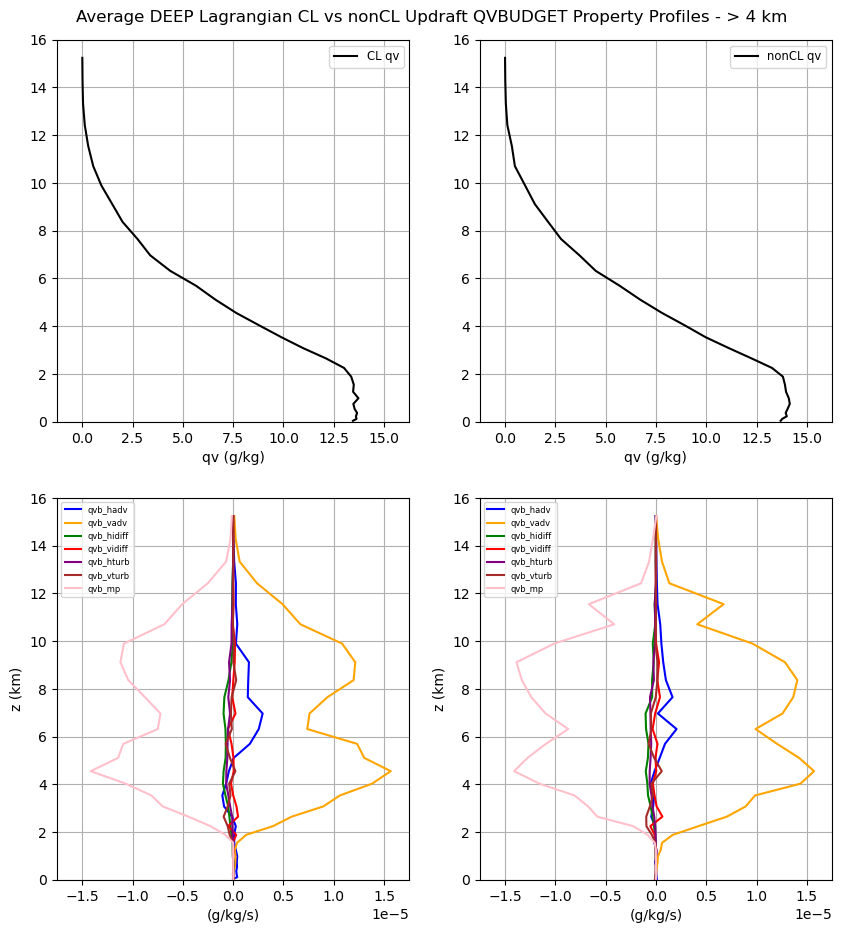

In [68]:
#QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"Average DEEP Lagrangian CL vs nonCL Updraft QVBUDGET Property Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4 = axs.flatten()

####################################################################
for type in ["CL","nonCL"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='CL':
            input_file=dir+f'tracking_algorithms/plots/job_out/CL_lagrangian_QVBUDGET_DEEP_profile.h5'
        elif type=='nonCL':
            input_file=dir+f'tracking_algorithms/plots/job_out/nonCL_lagrangian_QVBUDGET_DEEP_profile.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    out_qv[:,0]*=1000
    
    if type=='CL':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis.set_xlim(left=(0-0.5*2.5),right=(15+0.5*2.5))

    if type=='nonCL':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis.set_xlim(left=(0-0.5*2.5),right=(15+0.5*2.5))

    if type=='CL':
        for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
            axis=ax3
            plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
            axis.set_ylim(bottom=0,top=16)
            axis.set_ylabel('z (km)');
            axis.set_xlabel('(g/kg/s)')
            axis.legend(loc='upper left', fontsize=6); #add legend
            
    if type=='nonCL':
        for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
            axis=ax4
            plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
            axis.set_ylim(bottom=0,top=16)
            axis.set_ylabel('z (km)');
            axis.set_xlabel('(g/kg/s)')
            axis.legend(loc='upper left', fontsize=6); #add legend

    if type=='CL':
        axis.set_xlim(left=(-1.5-0.5*0.5)*1e-5,right=(1.5+0.5*0.5)*1e-5)
    elif type=='nonCL':
        axis.set_xlim(left=(-1.5-0.5*0.5)*1e-5,right=(1.5+0.5*0.5)*1e-5)


    # ax1.set_ylim((0,2))
    # ax2.set_ylim((0,2))
    # ax3.set_ylim((0,2))
    # ax4.set_ylim((0,2))

    # ax3.set_xlim((-0.5e-5,0.5e-5))
    # ax4.set_xlim((-0.5e-5,0.5e-5))
#save plot
if dim=='1km':
    plt.savefig(dir+f'tracking_algorithms/plots/CLvsnonCL_lagrangian_QVBUDGET_DEEP_profile.jpg', bbox_inches='tight', dpi=300) 


In [ ]:
#############################################
#SHALLOW

In [16]:
#ALL Convective Parcels Profile
##### viewing tracking algorithm results
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.colors as colors
# import matplotlib.ticker as ticker
# import matplotlib.cm as cm
# from matplotlib.colors import Normalize
# import matplotlib.gridspec as gridspec
# import xarray as xr
# import os; import time
# import h5py

# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/Project/'
# data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# parcel=xr.open_dataset(dir+'cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# whereCL=xr.open_dataset(dir+'tracking_algorithms/whereCL_4_0622.nc').load() #***
# whereCL=whereCL.isel(time=slice(0,len(data['time'])))

In [69]:
#OUT_NZ

# out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***


out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_combined.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_combined.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

out_nz=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_nz[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_nz[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_nz[:,0] == elem)[0] 
    extras=idx[np.where(out_nz[idx,5]!=np.min(out_nz[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_nz), dtype=bool); mask[lst] = False
out_nz=out_nz[mask]; 

###############################################################################

out_nz=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];print('list of first 10 ignored parcels');print(save_nz[:5])
placeholder1=out_nz.copy(); run=True
placeholder2=save_nz.copy(); run=True
# print(f'there are a total of {len(out_nz)} SBZ parcels and {len(save_nz)} forgotten parcels')

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def threshold_out(zthresh):
    out_nz=placeholder1.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<zthresh): #<shallow, >deep
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz, extendrange
    # print(out_nz)
##############################################################
def threshold_save(zthresh):
    save_nz=placeholder2.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(save_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(save_nz[ind,5],save_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=save_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<zthresh): #<shallow,>deep
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    save_nz=save_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(save_nz)} leftover parcels')
    return save_nz, extendrange
    # print(save_nz)
##############################################################

convectivelevel=4 #6km
[out_nz,extendrange]=threshold_out(convectivelevel)
[save_nz,extendrange]=threshold_save(convectivelevel)

print('list of first 10 SBZ parcels'); print(out_nz[:15])
print(f'there are a total of {len(out_nz)} CL parcels and {len(save_nz)} non-CL parcels')

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
list of first 10 ignored parcels
[[34 302 76 0.7418956298828125 34 37]
 [246 338 77 0.33685012817382814 2 11]
 [365 357 3 0.658669677734375 115 121]
 [363 440 62 0.18019241333007813 6 14]
 [483 465 43 0.2835696716308594 27 33]]
list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 

In [70]:
def grid_location(x,y,z):
    xf=data['xf'].values*1000; which_xh=np.searchsorted(xf,x)-1; which_xh=np.where(which_xh == -1, 0, which_xh) #finds which x layer parcel in
    yf=data['yf'].values*1000; which_yh=np.searchsorted(yf,y)-1; which_yh=np.where(which_yh == -1, 0, which_yh) #finds which y layer parcel in
    zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in     
    return which_zh,which_yh,which_xh

x=parcel['x'];y=parcel['y'];z=parcel['z']
which_z,which_y,which_x=grid_location(x,y,z)

#Makes np.where style mask for CL parcel locations
######################################################

#Setting up run for CL convective parcels
# np.arange(Np)==>out_nz[:,0]
# np.arange(Nt)==>out_nz[:,4]
col4 = out_nz[:, 4].astype(int)
# col5 = out_nz[:, 5].astype(int)
col5 = out_nz[:, 5].astype(int) + 2 #add another 10 minutes to each trajectory
ranges = [np.arange(start, end + 1) for start, end in zip(col4, col5)]
indexes = out_nz[:,0]
indexranges = [np.full_like(r, fill_value=index) for r, index in zip(ranges, indexes)]
totalelements=sum(len(arr) for arr in ranges)
print(f'running for total of {totalelements} elements')


CL_t,CL_z,CL_y,CL_x=[],[],[],[]
for R in np.arange(len(ranges)):
    tup=(ranges[R],indexranges[R])
    CL_t.extend(ranges[R])
    CL_z.extend(which_z[tup])
    CL_y.extend(which_y[tup])
    CL_x.extend(which_x[tup])
CL_t=np.array(CL_t);CL_z=np.array(CL_z);CL_y=np.array(CL_y);CL_x=np.array(CL_x)
CLposition=(CL_t, CL_z, CL_y, CL_x)
print('done')

#####################################################################################

#Makes np.where style mask for nonCL parcel locations
######################################################
out_nz=save_nz.copy() #out_nz is actually save_nz for code below

#Setting up run for nonCL convective parcels
# np.arange(Np)==>out_nz[:,0]
# np.arange(Nt)==>out_nz[:,4]
col4 = out_nz[:, 4].astype(int)
# col5 = out_nz[:, 5].astype(int)
col5 = out_nz[:, 5].astype(int) + 2 #add another 10 minutes to each trajectory
ranges = [np.arange(start, end + 1) for start, end in zip(col4, col5)]
indexes = out_nz[:,0]
indexranges = [np.full_like(r, fill_value=index) for r, index in zip(ranges, indexes)]
totalelements=sum(len(arr) for arr in ranges)
print(f'running for total of {totalelements} elements')


nonCL_t,nonCL_z,nonCL_y,nonCL_x=[],[],[],[]
for R in np.arange(len(ranges)):
    tup=(ranges[R],indexranges[R])
    nonCL_t.extend(ranges[R])
    nonCL_z.extend(which_z[tup])
    nonCL_y.extend(which_y[tup])
    nonCL_x.extend(which_x[tup])
nonCL_t=np.array(nonCL_t);nonCL_z=np.array(nonCL_z);nonCL_y=np.array(nonCL_y);nonCL_x=np.array(nonCL_x)
nonCLposition=(nonCL_t, nonCL_z, nonCL_y, nonCL_x)
print('done')

running for total of 9717 elements
done
running for total of 8915 elements
done


In [71]:
#CL vs nonCL Parcels Lagrangian Parcels Profile (OPTIMIZED) 

#W Budgets

#Making vertical profile of cloudy updrafts
print('loading neccessary variables')
if 'emptylike' not in globals():

    #Full Variables (W, QV, QC, QI)
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qv data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qi data
    qc_plus_qi=qc_data+qi_data
    emptylike=True
    
#W Budget Variables
variable='wb_hadv'; one_data=data[variable].data #'w budget: horizontal advection (non-diff component)'
variable='wb_vadv'; two_data=data[variable].data #'w budget: vertical advection (non-diff component)'
variable='wb_hidiff'; three_data=data[variable].data #'w budget: horiz implicit diffusion'
variable='wb_vidiff'; four_data=data[variable].data #'w budget: vert implicit diffusion'
variable='wb_hturb'; five_data=data[variable].data #'w budget: horizontal parameterized turbulence'
variable='wb_vturb'; six_data=data[variable].data #'w budget: vertical parameterized turbulence'
variable='wb_pgrad'; seven_data=data[variable].data #'w budget: pressure gradient'
variable='wb_rdamp'; eight_data=data[variable].data #'w budget: Rayleigh damper'
variable='wb_buoy'; nine_data=data[variable].data #'w budget: buoyancy'

print('done loading')


types=['CL','nonCL']
vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_rdamp',
    'wb_buoy'
]
for type in types:
    print(f"type {type}")
    if type=='CL':
        position=CLposition
    elif type=='nonCL':
        position=nonCLposition

    # #creates profile storage and adds z column  
    global all_thresh
    all_thresh=-1e6
   
    
    #create profile array
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    # position=(which_t.flatten(), which_z.flatten(), which_y.values.flatten(), which_x.values.flatten())
    lagrangian_w=w_data[position]
    lagrangian_qcplusqi=qc_plus_qi[position]
    
    for var in vars:
        print(f"variable {var}")
        if var=='w':
            lagrangian_var=w_data[position]
        elif var=='wb_hadv':
            lagrangian_var=one_data[position]
        elif var=='wb_vadv':
            lagrangian_var=two_data[position] 
        elif var=='wb_hidiff':
            lagrangian_var=three_data[position]
        elif var=='wb_vidiff':
            lagrangian_var=four_data[position] 
        elif var=='wb_hturb':
            lagrangian_var=five_data[position]
        elif var=='wb_vturb':
            lagrangian_var=six_data[position] 
        elif var=='wb_pgrad':
            lagrangian_var=seven_data[position]
        elif var=='wb_rdamp':
            lagrangian_var=eight_data[position] 
        elif var=='wb_buoy':
            lagrangian_var=nine_data[position] 

              
        #if w_zdata greater than threshold, add to profile z column and add count
        if type=='CL':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=CL_z.flatten()[np.where(lagrangian_w>=all_thresh)]
        elif type=='nonCL':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=nonCL_z.flatten()[np.where(lagrangian_w>=all_thresh)]
        
            
        for count,(kh,value) in enumerate(zip(masked_z,masked_var)):
            # if np.mod(count,200)==0: print(f"{np.round(count*100/len(masked_z),1)}% done")
            globals()[f"profile_{var}"][kh,0]+=value #adds data to first column
            globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column
    
    if type=='CL':
        output_file=dir+f'tracking_algorithms/plots/job_out/CL_lagrangian_WBUDGET_SHALLOW_profile.h5'
    elif type=='nonCL':
        output_file=dir+f'tracking_algorithms/plots/job_out/nonCL_lagrangian_WBUDGET_SHALLOW_profile.h5'
        
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_w', data=profile_w, compression="gzip")
        f.create_dataset('profile_wb_hadv', data=profile_wb_hadv, compression="gzip")
        f.create_dataset('profile_wb_vadv', data=profile_wb_vadv, compression="gzip")
        f.create_dataset('profile_wb_hidiff', data=profile_wb_hidiff, compression="gzip")
        f.create_dataset('profile_wb_vidiff', data=profile_wb_vidiff, compression="gzip")
        f.create_dataset('profile_wb_hturb', data=profile_wb_hturb, compression="gzip")
        f.create_dataset('profile_wb_vturb', data=profile_wb_vturb, compression="gzip")
        f.create_dataset('profile_wb_pgrad', data=profile_wb_pgrad, compression="gzip")
        f.create_dataset('profile_wb_rdamp', data=profile_wb_rdamp, compression="gzip")
        f.create_dataset('profile_wb_buoy', data=profile_wb_buoy, compression="gzip")
    print('done') 

loading neccessary variables
done loading
type CL
variable w
variable wb_hadv
variable wb_vadv
variable wb_hidiff
variable wb_vidiff
variable wb_hturb
variable wb_vturb
variable wb_pgrad
variable wb_rdamp
variable wb_buoy
done
type nonCL
variable w
variable wb_hadv
variable wb_vadv
variable wb_hidiff
variable wb_vidiff
variable wb_hturb
variable wb_vturb
variable wb_pgrad
variable wb_rdamp
variable wb_buoy
done


currently on type CL
currently on type nonCL


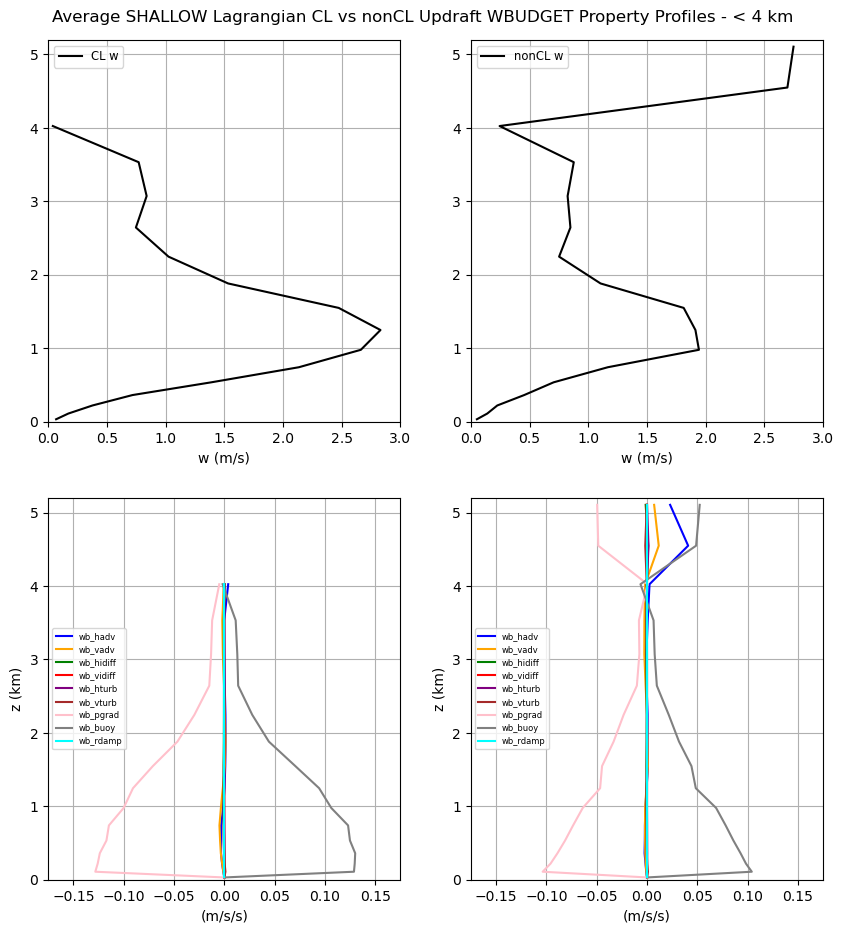

In [44]:
#W BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"Average SHALLOW Lagrangian CL vs nonCL Updraft WBUDGET Property Profiles - < {convectivelevel} km")
ax1, ax2, ax3, ax4 = axs.flatten()

####################################################################
for type in ["CL","nonCL"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='CL':
            input_file=dir+f'tracking_algorithms/plots/job_out/CL_lagrangian_WBUDGET_SHALLOW_profile.h5'
        elif type=='nonCL':
            input_file=dir+f'tracking_algorithms/plots/job_out/nonCL_lagrangian_WBUDGET_SHALLOW_profile.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_rdamp = np.array(f['profile_wb_rdamp'])  # w budget: Rayleigh damper
        profile_wb_buoy = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy',
    'wb_rdamp'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

        var=globals()[f"out_{var}"].copy()

    if type=='CL':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        axis.set_ylim(bottom=0,top=5.2)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis.set_xlim(0,3)

    if type=='nonCL':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        axis.set_ylim(bottom=0,top=5.2)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper left', fontsize='small'); #add legend
        axis.set_xlim(0,3)

    if type=='CL':
        for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
            axis=ax3
            plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
            axis.set_ylim(bottom=0,top=5.2)
            axis.set_ylabel('z (km)');
            axis.set_xlabel('(m/s/s)')
            axis.legend(loc='center left', fontsize=6); #add legend
            
    if type=='nonCL':
        for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
            axis=ax4
            plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
            axis.set_ylim(bottom=0,top=5.2)
            axis.set_ylabel('z (km)');
            axis.set_xlabel('(m/s/s)')
            axis.legend(loc='center left', fontsize=6); #add legend
            
    if type=='CL':
        axis.set_xlim(left=(-0.15-0.5*0.05),right=(0.15+0.5*0.05))
    elif type=='nonCL':
        axis.set_xlim(left=(-0.15-0.5*0.05),right=(0.15+0.5*0.05))

#save plot
if dim=='1km':
    plt.savefig(dir+f'tracking_algorithms/plots/CLvsnonCL_lagrangian_WBUDGET_SHALLOW_profile.jpg', bbox_inches='tight', dpi=300) 


In [73]:
#CL vs nonCL Parcels Lagrangian Parcels Profile (OPTIMIZED) 

#QV Budgets

#Making vertical profile of cloudy updrafts
print('loading neccessary variables')
if 'emptylike' not in globals():

    #Full Variables (W, QV, QC, QI)
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qv data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qi data
    qc_plus_qi=qc_data+qi_data
    emptylike=True
    
#QV Budget Variables
variable='qvb_hadv'; one_data=data[variable].data #'w budget: horizontal advection (non-diff component)'
variable='qvb_vadv'; two_data=data[variable].data #'w budget: vertical advection (non-diff component)'
variable='qvb_hidiff'; three_data=data[variable].data #'w budget: horiz implicit diffusion'
variable='qvb_vidiff'; four_data=data[variable].data #'w budget: vert implicit diffusion'
variable='qvb_hturb'; five_data=data[variable].data #'w budget: horizontal parameterized turbulence'
variable='qvb_vturb'; six_data=data[variable].data #'w budget: vertical parameterized turbulence'
variable='qvb_mp'; seven_data=data[variable].data #'w budget: pressure gradient'
print('done loading')


types=['CL','nonCL']
vars = [
    'qv',
    'qvb_hadv',
    'qvb_vadv',
    'qvb_hidiff',
    'qvb_vidiff',
    'qvb_hturb',
    'qvb_vturb',
    'qvb_mp'
]
for type in types:
    print(f"type {type}")
    if type=='CL':
        position=CLposition
    elif type=='nonCL':
        position=nonCLposition

    # #creates profile storage and adds z column  
    global all_thresh
    all_thresh=-1e6
   
    
    #create profile array
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    # position=(which_t.flatten(), which_z.flatten(), which_y.values.flatten(), which_x.values.flatten())
    lagrangian_w=w_data[position]
    lagrangian_qcplusqi=qc_plus_qi[position]
    
    for var in vars:
        print(f"variable {var}")
        if var=='qv':
            lagrangian_var=qv_data[position]
        elif var=='qvb_hadv':
            lagrangian_var=one_data[position]
        elif var=='qvb_vadv':
            lagrangian_var=two_data[position] 
        elif var=='qvb_hidiff':
            lagrangian_var=three_data[position]
        elif var=='qvb_vidiff':
            lagrangian_var=four_data[position] 
        elif var=='qvb_hturb':
            lagrangian_var=five_data[position]
        elif var=='qvb_vturb':
            lagrangian_var=six_data[position] 
        elif var=='qvb_mp':
            lagrangian_var=seven_data[position]

              
        #if w_zdata greater than threshold, add to profile z column and add count
        if type=='CL':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=CL_z.flatten()[np.where(lagrangian_w>=all_thresh)]
        elif type=='nonCL':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=nonCL_z.flatten()[np.where(lagrangian_w>=all_thresh)]
        
            
        for count,(kh,value) in enumerate(zip(masked_z,masked_var)):
            # if np.mod(count,200)==0: print(f"{np.round(count*100/len(masked_z),1)}% done")
            globals()[f"profile_{var}"][kh,0]+=value #adds data to first column
            globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column
    
    if type=='CL':
        output_file=dir+f'tracking_algorithms/plots/job_out/CL_lagrangian_QVBUDGET_SHALLOW_profile.h5'
    elif type=='nonCL':
        output_file=dir+f'tracking_algorithms/plots/job_out/nonCL_lagrangian_QVBUDGET_SHALLOW_profile.h5'
        
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
        f.create_dataset('profile_qvb_hadv', data=profile_qvb_hadv, compression="gzip")
        f.create_dataset('profile_qvb_vadv', data=profile_qvb_vadv, compression="gzip")
        f.create_dataset('profile_qvb_hidiff', data=profile_qvb_hidiff, compression="gzip")
        f.create_dataset('profile_qvb_vidiff', data=profile_qvb_vidiff, compression="gzip")
        f.create_dataset('profile_qvb_hturb', data=profile_qvb_hturb, compression="gzip")
        f.create_dataset('profile_qvb_vturb', data=profile_qvb_vturb, compression="gzip")
        f.create_dataset('profile_qvb_mp', data=profile_qvb_mp, compression="gzip")
    print('done')

loading neccessary variables
done loading
type CL
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done
type nonCL
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done


currently on type CL
currently on type nonCL


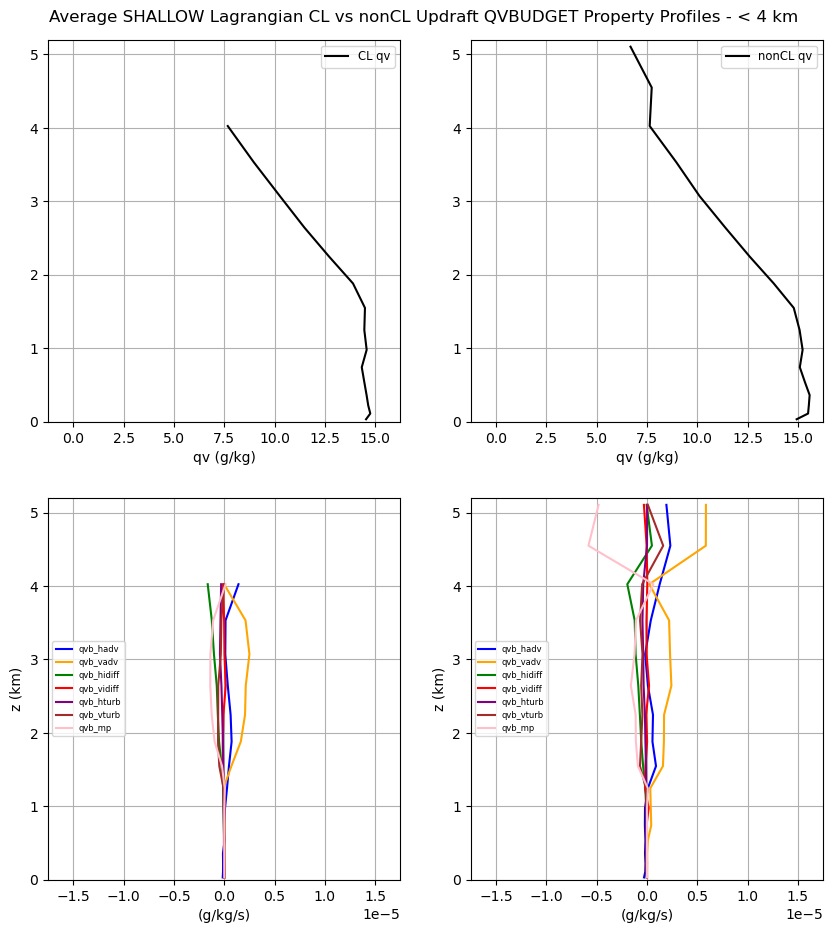

In [73]:
#QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"Average SHALLOW Lagrangian CL vs nonCL Updraft QVBUDGET Property Profiles - < {convectivelevel} km")
ax1, ax2, ax3, ax4 = axs.flatten()

####################################################################
for type in ["CL","nonCL"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='CL':
            input_file=dir+f'tracking_algorithms/plots/job_out/CL_lagrangian_QVBUDGET_SHALLOW_profile.h5'
        elif type=='nonCL':
            input_file=dir+f'tracking_algorithms/plots/job_out/nonCL_lagrangian_QVBUDGET_SHALLOW_profile.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    out_qv[:,0]*=1000

    if type=='CL':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        axis.set_ylim(bottom=0,top=5.2)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis.set_xlim(left=(0-0.5*2.5),right=(15+0.5*2.5))

    if type=='nonCL':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        axis.set_ylim(bottom=0,top=5.2)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis.set_xlim(left=(0-0.5*2.5),right=(15+0.5*2.5))

    if type=='CL':
        for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
            axis=ax3
            plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
            axis.set_ylim(bottom=0,top=5.2)
            axis.set_ylabel('z (km)');
            axis.set_xlabel('(g/kg/s)')
            axis.legend(loc='center left', fontsize=6); #add legend
            
    if type=='nonCL':
        for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
            axis=ax4
            plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
            axis.set_ylim(bottom=0,top=5.2)
            axis.set_ylabel('z (km)');
            axis.set_xlabel('(g/kg/s)')
            axis.legend(loc='center left', fontsize=6); #add legend

    if type=='CL':
        axis.set_xlim(left=(-1.5-0.5*0.5)*1e-5,right=(1.5+0.5*0.5)*1e-5)
    elif type=='nonCL':
        axis.set_xlim(left=(-1.5-0.5*0.5)*1e-5,right=(1.5+0.5*0.5)*1e-5)


    # ax1.set_ylim((0,2))
    # ax2.set_ylim((0,2))
    # ax3.set_ylim((0,2))
    # ax4.set_ylim((0,2))

    # ax3.set_xlim((-0.5e-5,0.5e-5))
    # ax4.set_xlim((-0.5e-5,0.5e-5))
#save plot
if dim=='1km':
    plt.savefig(dir+f'tracking_algorithms/plots/CLvsnonCL_lagrangian_QVBUDGET_SHALLOW_profile.jpg', bbox_inches='tight', dpi=300) 
